# Movie / cinema domain

Refactored screen-title domain. Generates Russian and English queries for films, TV series, animated films, and short films. Uses Wikidata for entity/gold candidates and local IMDb datasets for ratings, runtime, title type, votes, and canonical year filters. Kinopoisk API is not used.

This version adds more natural and diverse patterns: L1-L2 no longer use country as a main criterion; L3-L5 include rating-only, runtime-only, optional votes, actor/director/production-company bridges, and mixed hard multi-constraint patterns.

In [1]:

# Load common helpers only if this domain notebook is run standalone.
from pathlib import Path
if "BenchmarkExample" not in globals():
    exec(Path("common_helpers.py").read_text(encoding="utf-8"), globals())

# Movie / screen domain config.
# This notebook intentionally replaces the old Kinopoisk extension.
# Ratings are taken from official IMDb non-commercial datasets cached locally.
from pathlib import Path
import gzip
import shutil

MOVIE_DOMAIN_NAME = "movie"          # stored in each generated example
CINEMA_BACKCOMPAT_KEY = "cinema"     # backward-compatible generator key in old TARGET_MAIN

IMDB_DATA_DIR = Path(OUT_DIR) / "imdb_cache"
IMDB_DATA_DIR.mkdir(parents=True, exist_ok=True)

IMDB_DATASET_URLS = {
    "title.basics.tsv.gz": "https://datasets.imdbws.com/title.basics.tsv.gz",
    "title.ratings.tsv.gz": "https://datasets.imdbws.com/title.ratings.tsv.gz",
}

# If True, the notebook will download title.basics + title.ratings when missing.
# They are reused from cache afterwards and avoid per-request API limits.
IMDB_AUTO_DOWNLOAD = True

# Candidate limits: WDQS first returns candidates; IMDb cache then applies rating/runtime/titleType filters.
MOVIE_WDQS_LIMIT = 600
MOVIE_GOLD_LIMIT = 300

# Basic Wikidata classes.
Q_FILM = "Q11424"
Q_TV_SERIES = "Q5398426"
Q_ANIMATED_FILM = "Q202866"
Q_SHORT_FILM = "Q24862"
Q_TV_FILM = "Q506240"

MOVIE_COUNTRIES = [
    {"ru":"США", "en":"United States of America", "qid":"Q30"},
    {"ru":"Великобритания", "en":"United Kingdom", "qid":"Q145"},
    {"ru":"Франция", "en":"France", "qid":"Q142"},
    {"ru":"Италия", "en":"Italy", "qid":"Q38"},
    {"ru":"Япония", "en":"Japan", "qid":"Q17"},
    {"ru":"Канада", "en":"Canada", "qid":"Q16"},
    {"ru":"Германия", "en":"Germany", "qid":"Q183"},
    {"ru":"Индия", "en":"India", "qid":"Q668"},
    {"ru":"Испания", "en":"Spain", "qid":"Q29"},
    {"ru":"Южная Корея", "en":"South Korea", "qid":"Q884"},
]

MOVIE_GENRES = [
    # en is the clean user-facing constraint label; wd_label_en keeps the more Wikidata-like name for reference.
    {"ru":"драма", "en":"drama", "wd_label_en":"drama film", "qid":"Q130232", "imdb":"Drama"},
    {"ru":"комедия", "en":"comedy", "wd_label_en":"comedy film", "qid":"Q157443", "imdb":"Comedy"},
    {"ru":"триллер", "en":"thriller", "wd_label_en":"thriller film", "qid":"Q2484376", "imdb":"Thriller"},
    {"ru":"фильм ужасов", "en":"horror", "wd_label_en":"horror film", "qid":"Q200092", "imdb":"Horror"},
    {"ru":"боевик", "en":"action", "wd_label_en":"action film", "qid":"Q188473", "imdb":"Action"},
    {"ru":"криминальный фильм", "en":"crime", "wd_label_en":"crime film", "qid":"Q959790", "imdb":"Crime"},
    {"ru":"научная фантастика", "en":"sci-fi", "wd_label_en":"science fiction film", "qid":"Q471839", "imdb":"Sci-Fi"},
    {"ru":"документальное кино", "en":"documentary", "wd_label_en":"documentary film", "qid":"Q93204", "imdb":"Documentary"},
]

MOVIE_KINDS = {
    "film": {
        "ru_acc": "фильмов",
        "en_plural": "films",
        "class_qid": Q_FILM,
        "title_types": {"movie"},
        "wd_exclude_classes": [],
        "constraints_extra": {},
    },
    "feature_film": {
        "ru_acc": "полнометражных фильмов",
        "en_plural": "feature films",
        "class_qid": Q_FILM,
        "title_types": {"movie"},
        "wd_exclude_classes": [Q_TV_FILM, Q_SHORT_FILM, Q_ANIMATED_FILM],
        "constraints_extra": {"full_length_only": True},
        "runtime_min_minutes": 60,
    },
    "tv_series": {
        "ru_acc": "сериалов",
        "en_plural": "TV series",
        "class_qid": Q_TV_SERIES,
        "title_types": {"tvSeries", "tvMiniSeries"},
        "wd_exclude_classes": [],
        "constraints_extra": {},
    },
    "animated_film": {
        "ru_acc": "мультфильмов",
        "en_plural": "animated films",
        "class_qid": Q_ANIMATED_FILM,
        "title_types": {"movie"},
        "wd_exclude_classes": [Q_TV_FILM, Q_SHORT_FILM],
        "constraints_extra": {"animation_only": True},
        "imdb_genre_required": "Animation",
    },
    "short_film": {
        "ru_acc": "короткометражных фильмов",
        "en_plural": "short films",
        "class_qid": Q_SHORT_FILM,
        "title_types": {"short"},
        "wd_exclude_classes": [],
        "constraints_extra": {},
        "runtime_max_minutes": 45,
    },
}

MOVIE_SEEDS = [
    {"ru":"Начало", "en":"Inception", "qid":"Q43361", "kind":"feature_film"},
    {"ru":"Матрица", "en":"The Matrix", "qid":"Q83495", "kind":"feature_film"},
    {"ru":"Крёстный отец", "en":"The Godfather", "qid":"Q47703", "kind":"feature_film"},
    {"ru":"Семь", "en":"Seven", "qid":"Q314829", "kind":"feature_film"},
    {"ru":"Тёмный рыцарь", "en":"The Dark Knight", "qid":"Q163872", "kind":"feature_film"},
    {"ru":"Криминальное чтиво", "en":"Pulp Fiction", "qid":"Q104123", "kind":"feature_film"},
    {"ru":"История игрушек", "en":"Toy Story", "qid":"Q171048", "kind":"animated_film"},
    {"ru":"Шрек", "en":"Shrek", "qid":"Q483396", "kind":"animated_film"},
    {"ru":"Унесённые призраками", "en":"Spirited Away", "qid":"Q155653", "kind":"animated_film"},
    {"ru":"Во все тяжкие", "en":"Breaking Bad", "qid":"Q826477", "kind":"tv_series"},
    {"ru":"Игра престолов", "en":"Game of Thrones", "qid":"Q23572", "kind":"tv_series"},
    {"ru":"Симпсоны", "en":"The Simpsons", "qid":"Q886", "kind":"tv_series"},
    {"ru":"Друзья", "en":"Friends", "qid":"Q79784", "kind":"tv_series"},
    {"ru":"Офис", "en":"The Office", "qid":"Q23831", "kind":"tv_series"},
    {"ru":"Очень странные дела", "en":"Stranger Things", "qid":"Q19798734", "kind":"tv_series"},
    {"ru":"Инопланетянин", "en":"E.T. the Extra-Terrestrial", "qid":"Q11621", "kind":"feature_film"},
    {"ru":"Парк юрского периода", "en":"Jurassic Park", "qid":"Q167726", "kind":"feature_film"},
    {"ru":"Бешеные псы", "en":"Reservoir Dogs", "qid":"Q72962", "kind":"feature_film"},
    {"ru":"ВАЛЛ-И", "en":"WALL-E", "qid":"Q104905", "kind":"animated_film"},
]

IMDB_RATING_MIN_THRESHOLDS = [6.0, 6.5, 7.0, 7.5, 8.0]
IMDB_RATING_MAX_THRESHOLDS = [4.5, 5.0, 5.5, 6.0, 6.5]
# Backward-compatible alias if other cells refer to it.
IMDB_RATING_THRESHOLDS = IMDB_RATING_MIN_THRESHOLDS
IMDB_VOTE_THRESHOLDS = [500, 1000, 3000, 5000, 10000, 25000, 50000]
RUNTIME_BUCKETS = [(60, 120), (80, 140), (90, 160), (100, 180), (None, 120), (None, 150), (90, None)]

YEAR_BUCKETS = [
    (1980, 1999),
    (1990, 2009),
    (2000, 2015),
    (2010, 2020),
    (2015, 2025),
]


✅ Patched: WikidataClient.sparql_select (robust) + load_or_build_pool (safe)
✅ Patched: select_items_with_* используют ru/en fallback + repair_pool_labels чинит QID вместо label


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## IMDb local cache

Downloads/loads official IMDb non-commercial datasets once and reuses them from `out_wikidata_benchmark/imdb_cache`.

In [2]:

def _download_file(url: str, path: Path, chunk_size: int = 1024 * 1024) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    print(f"[IMDb] downloading {url} -> {path}")
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(tmp, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
    os.replace(tmp, path)


def ensure_imdb_dataset_files(auto_download: bool = IMDB_AUTO_DOWNLOAD) -> Dict[str, Path]:
    paths = {name: IMDB_DATA_DIR / name for name in IMDB_DATASET_URLS}
    missing = [name for name, p in paths.items() if not p.exists()]
    if missing and not auto_download:
        raise FileNotFoundError(
            "Missing IMDb dataset files: " + ", ".join(missing) +
            f". Put them into {IMDB_DATA_DIR} or set IMDB_AUTO_DOWNLOAD=True."
        )
    for name in missing:
        _download_file(IMDB_DATASET_URLS[name], paths[name])
    return paths


def load_imdb_title_cache(force_rebuild: bool = False) -> Dict[str, Dict[str, Any]]:
    """Load IMDb title.basics + title.ratings into a lightweight local dict by tconst.
    This avoids OMDb/Kinopoisk per-hour API limits during generation.
    """
    cache_path = IMDB_DATA_DIR / "imdb_title_ratings_cache_v1.json"
    if cache_path.exists() and not force_rebuild:
        with open(cache_path, "r", encoding="utf-8") as f:
            return json.load(f)

    paths = ensure_imdb_dataset_files()
    print("[IMDb] reading title.ratings.tsv.gz")
    ratings = pd.read_csv(
        paths["title.ratings.tsv.gz"],
        sep="\t",
        dtype={"tconst": "string"},
        usecols=["tconst", "averageRating", "numVotes"],
    )
    ratings["averageRating"] = pd.to_numeric(ratings["averageRating"], errors="coerce")
    ratings["numVotes"] = pd.to_numeric(ratings["numVotes"], errors="coerce").fillna(0).astype(int)

    print("[IMDb] reading title.basics.tsv.gz; this can take a little while once")
    basics = pd.read_csv(
        paths["title.basics.tsv.gz"],
        sep="\t",
        dtype="string",
        na_values="\\N",
        usecols=["tconst", "titleType", "primaryTitle", "startYear", "runtimeMinutes", "genres"],
    )
    merged = basics.merge(ratings, on="tconst", how="inner")
    merged["startYear"] = pd.to_numeric(merged["startYear"], errors="coerce")
    merged["runtimeMinutes"] = pd.to_numeric(merged["runtimeMinutes"], errors="coerce")

    # Keep only screen-title types useful for this domain.
    wanted_types = {"movie", "short", "tvMovie", "tvSeries", "tvMiniSeries"}
    merged = merged[merged["titleType"].isin(wanted_types)].copy()

    out = {}
    for row in merged.itertuples(index=False):
        tconst = str(row.tconst)
        out[tconst] = {
            "titleType": None if pd.isna(row.titleType) else str(row.titleType),
            "primaryTitle": None if pd.isna(row.primaryTitle) else str(row.primaryTitle),
            "startYear": None if pd.isna(row.startYear) else int(row.startYear),
            "runtimeMinutes": None if pd.isna(row.runtimeMinutes) else int(row.runtimeMinutes),
            "genres": [] if pd.isna(row.genres) else [g.strip() for g in str(row.genres).split(",") if g.strip()],
            "averageRating": None if pd.isna(row.averageRating) else float(row.averageRating),
            "numVotes": int(row.numVotes) if not pd.isna(row.numVotes) else 0,
        }
    with open(cache_path, "w", encoding="utf-8") as f:
        json.dump(out, f, ensure_ascii=False)
    print(f"[IMDb] cached {len(out):,} titles -> {cache_path}")
    return out


def _imdb_norm(imdb_id: Optional[str]) -> Optional[str]:
    if not imdb_id:
        return None
    s = str(imdb_id).strip()
    if not s:
        return None
    if s.startswith("tt"):
        return s
    if s.isdigit():
        return "tt" + s.zfill(7)
    return s

_IMDB_CACHE = None

def imdb_cache() -> Dict[str, Dict[str, Any]]:
    global _IMDB_CACHE
    if _IMDB_CACHE is None:
        _IMDB_CACHE = load_imdb_title_cache()
    return _IMDB_CACHE


## Wikidata candidate collection and IMDb filtering

In [3]:

def _movie_kind_cfg(kind: str) -> Dict[str, Any]:
    return MOVIE_KINDS[kind]


def _movie_class_where(kind: str, item_var: str = "item") -> List[str]:
    cfg = _movie_kind_cfg(kind)
    lines = [f"?{item_var} wdt:P31/wdt:P279* wd:{cfg['class_qid']} ."]
    for q in cfg.get("wd_exclude_classes", []) or []:
        lines.append(f"FILTER NOT EXISTS {{ ?{item_var} wdt:P31/wdt:P279* wd:{q} . }}")
    lines.append(f"?{item_var} wdt:P345 ?imdb .")
    return lines


def movie_select_candidates(where_lines: List[str], limit: int = MOVIE_WDQS_LIMIT, item_var: str = "item") -> Tuple[str, List[Dict[str, Any]]]:
    where = "\n      ".join(where_lines)
    sparql = f"""
    SELECT DISTINCT ?{item_var} ?imdb ?{item_var}LabelEn ?{item_var}LabelRu WHERE {{
      {where}
      ?{item_var} rdfs:label ?{item_var}LabelEn FILTER(LANG(?{item_var}LabelEn) = "en") .
      OPTIONAL {{ ?{item_var} rdfs:label ?{item_var}LabelRu FILTER(LANG(?{item_var}LabelRu) = "ru") . }}
    }}
    LIMIT {int(limit)}
    """.strip()
    rows = rows_from_select(wd.sparql_select(sparql))
    out = []
    for r in rows:
        qid = uri_to_qid(r.get(item_var, ""))
        imdb = _imdb_norm(r.get("imdb"))
        en = r.get(f"{item_var}LabelEn")
        ru = r.get(f"{item_var}LabelRu") or en
        if qid and imdb and en:
            out.append({"qid": qid, "imdb": imdb, "label_en": en, "label_ru": ru})
    return sparql, out


def movie_filter_by_imdb(candidates: List[Dict[str, Any]], constraints: Dict[str, Any], kind_override: Optional[str] = None) -> List[Dict[str, Any]]:
    idx = imdb_cache()
    kind = kind_override or constraints.get("kind", "film")
    cfg = _movie_kind_cfg(kind if kind in MOVIE_KINDS else "film")
    allowed_types = set(cfg.get("title_types") or [])

    y1 = constraints.get("year_from")
    y2 = constraints.get("year_to")
    rating_min = constraints.get("rating_imdb_min")
    rating_max = constraints.get("rating_imdb_max")
    votes_min = constraints.get("votes_imdb_min", 0)
    rt_min = constraints.get("runtime_min_minutes", cfg.get("runtime_min_minutes"))
    rt_max = constraints.get("runtime_max_minutes", cfg.get("runtime_max_minutes"))
    genre_required = cfg.get("imdb_genre_required")

    out = []
    seen = set()
    for c in candidates:
        imdb_id = c.get("imdb")
        meta = idx.get(imdb_id)
        if not meta:
            continue
        if allowed_types and meta.get("titleType") not in allowed_types:
            continue
        year = meta.get("startYear")
        if y1 is not None and (year is None or year < int(y1)):
            continue
        if y2 is not None and (year is None or year > int(y2)):
            continue
        rating = meta.get("averageRating")
        if rating_min is not None and (rating is None or float(rating) < float(rating_min)):
            continue
        if rating_max is not None and (rating is None or float(rating) > float(rating_max)):
            continue
        votes = meta.get("numVotes") or 0
        if votes_min is not None and int(votes) < int(votes_min):
            continue
        runtime = meta.get("runtimeMinutes")
        if rt_min is not None and (runtime is None or int(runtime) < int(rt_min)):
            continue
        if rt_max is not None and (runtime is None or int(runtime) > int(rt_max)):
            continue
        if genre_required and genre_required not in (meta.get("genres") or []):
            continue
        qid = c["qid"]
        if qid in seen:
            continue
        seen.add(qid)
        c = dict(c)
        c["imdb_meta"] = meta
        out.append(c)
    return out


def build_movie_ask_validator(where_lines: List[str], item_var: str = "item") -> str:
    # ASK validates the Wikidata part. IMDb rating/runtime filters are stored in constraints.
    where = "\n      ".join(line for line in where_lines if "?imdb" not in line)
    return f"""
    ASK WHERE {{
      BIND(wd:{{ITEM}} AS ?{item_var})
      {where}
    }}
    """.strip()



def clean_movie_constraints_en(constraints: Dict[str, Any]) -> Dict[str, Any]:
    """Return final clean English constraints for dataset storage.

    Important: implementation filters for feature films are kept in SPARQL/IMDb validation,
    but the final user-facing constraints stay compact. For example, full_length_only=True
    already implies that we exclude TV movies, shorts and animated titles where needed;
    those hidden exclusions are not repeated as separate constraints.
    """
    banned = {
        "source_dataset", "source_file", "template_id", "template_family", "type",
        "qid", "qids", "sparql_query", "ask_validator_sparql", "date_properties",
        "text_clues", "full_constraints", "created_at", "is_advanced",
        "_score_min", "score", "rating", "movie_length_range", "year_range",
        "genre_ru", "country_ru", "seed_ru",
        # hidden implementation filters; full_length_only / kind already captures the semantic condition
        "not_tv_movie", "not_short_film", "not_animation",
    }
    out = {}
    for k, v in (constraints or {}).items():
        if k in banned or k.startswith("gold_") or k.startswith("template_"):
            continue
        if k.endswith("_qid") or k.endswith("_qids"):
            continue
        if k.endswith("_ru"):
            continue
        if v is None or v is False or v == "" or v == [] or v == {}:
            continue
        out[k] = v
    return out

def build_movie_record(
    idx: int,
    complexity: str,
    kind: str,
    constraints: Dict[str, Any],
    where_lines: List[str],
    query_text_ru: str,
    query_text_en: str,
    requested_count: int,
    template_id: str,
    max_gold: int = MOVIE_GOLD_LIMIT,
) -> Optional[BenchmarkExample]:
    try:
        sparql, candidates = movie_select_candidates(where_lines, limit=max(200, max_gold * 3))
    except Exception as e:
        if globals().get("DEBUG_GENERATOR_ERRORS", False):
            print("[movie] WDQS failed", template_id, e)
        return None

    filtered = movie_filter_by_imdb(candidates, constraints, kind_override=kind)
    if len(filtered) < requested_count:
        return None
    filtered = filtered[:max_gold]
    constraints_clean = clean_movie_constraints_en(constraints)
    qids = [x["qid"] for x in filtered]
    labels_en = [x["label_en"] for x in filtered]
    labels_ru = [x.get("label_ru") or x["label_en"] for x in filtered]

    # Add machine-readable note to SPARQL so audit sees which parts are local IMDb filters.
    local_note = "\n".join([f"# {k}: {v}" for k, v in constraints.items() if k.startswith("rating_") or k.startswith("votes_") or k.startswith("runtime_")])
    sparql_with_note = ("# IMDb-backed local filters applied after WDQS\n" + local_note + "\n" + sparql).strip()

    return BenchmarkExample(
        id=f"movie_{complexity.lower()}_{idx:04d}",
        domain=MOVIE_DOMAIN_NAME,
        complexity=complexity,
        query_text_ru=query_text_ru,
        query_text_en=query_text_en,
        constraints=constraints_clean,
        requested_count=requested_count,
        gold_answer_qids=qids,
        gold_answer_labels_ru=labels_ru,
        gold_answer_labels_en=labels_en,
        sparql_query=sparql_with_note,
        created_at=utc_now_z(),
        is_advanced=complexity in {"L3", "L4", "L5"},
        template_id=template_id,
        template_family="movie_imdb_wikidata",
        gold_truncated=len(filtered) >= max_gold,
        ask_validator_sparql=build_movie_ask_validator(where_lines),
    )


## Query text builders

In [4]:

def _weighted_choice(rng: random.Random, items: List[str], weights: List[float]) -> str:
    """Small wrapper around random.choices for deterministic weighted choices."""
    return rng.choices(items, weights=weights, k=1)[0]


def _pick_movie_kind(complexity: str, rng: random.Random) -> str:
    if complexity in {"L1", "L2"}:
        return rng.choice(["feature_film", "tv_series", "animated_film", "short_film"])
    if complexity == "L3":
        return rng.choice(["feature_film", "tv_series", "animated_film", "short_film"])
    if complexity in {"L4", "L5"}:
        # Hard levels should still be film-heavy, but not almost exclusively feature films.
        # A small but visible share of TV series / animated films keeps the movie domain diverse.
        return _weighted_choice(
            rng,
            ["feature_film", "tv_series", "animated_film", "short_film"],
            [0.56, 0.22, 0.17, 0.05],
        )
    return "feature_film"


def _pick_hard_title_kind_for_bridge(bridge: str, rng: random.Random) -> str:
    """Pick answer title kind for L4/L5 movie-answer bridge tasks.

    Director/production-company metadata is much more reliable for films than for series,
    so those bridges stay film/animation focused. Actor bridges can safely include series.
    """
    if bridge == "actor":
        return _weighted_choice(
            rng,
            ["feature_film", "tv_series", "animated_film", "short_film"],
            [0.50, 0.25, 0.20, 0.05],
        )
    if bridge == "director":
        return _weighted_choice(rng, ["feature_film", "animated_film", "tv_series"], [0.68, 0.22, 0.10])
    # Production company works best for films/animation; tiny TV share is allowed but rare.
    return _weighted_choice(rng, ["feature_film", "animated_film", "tv_series"], [0.72, 0.23, 0.05])


def _pick_actor_evidence_title_kind(bridge_key: str, rng: random.Random) -> str:
    """Pick evidence-title kind for actor-answer tasks."""
    if bridge_key in {"movie_director_from_object", "movie_production_company_from_object", "movie_composer_from_object"}:
        return _weighted_choice(rng, ["feature_film", "animated_film", "tv_series"], [0.68, 0.25, 0.07])
    return _weighted_choice(rng, ["feature_film", "tv_series", "animated_film"], [0.56, 0.26, 0.18])


def _year_phrase_ru(y1: int, y2: int) -> str:
    return f"{y1} года" if y1 == y2 else f"в период {y1}–{y2} годов"


def _year_phrase_en(y1: int, y2: int) -> str:
    return f"from {y1}" if y1 == y2 else f"from {y1} to {y2}"


def _ru_label_from_en(en_value: str, pool: List[Dict[str, str]]) -> str:
    for x in pool:
        if en_value in {x.get("en"), x.get("wd_label_en"), x.get("display_en")}:
            return x.get("ru") or en_value
    return en_value


def _en_display_from_en(en_value: str, pool: List[Dict[str, str]]) -> str:
    for x in pool:
        if en_value in {x.get("en"), x.get("wd_label_en"), x.get("display_en")}:
            return x.get("en") or en_value
    return en_value


def _append_runtime_phrase(ru_parts: List[str], en_parts: List[str], constraints: Dict[str, Any]) -> None:
    lo = constraints.get("runtime_min_minutes")
    hi = constraints.get("runtime_max_minutes")
    if lo is not None and hi is not None:
        ru_parts.append(f"длительностью {lo}–{hi} минут")
        en_parts.append(f"with runtime between {lo} and {hi} minutes")
    elif lo is not None:
        ru_parts.append(f"длительностью не менее {lo} минут")
        en_parts.append(f"with runtime at least {lo} minutes")
    elif hi is not None:
        ru_parts.append(f"длительностью не более {hi} минут")
        en_parts.append(f"with runtime at most {hi} minutes")


def nlg_movie_query(kind: str, constraints: Dict[str, Any], requested_count: int, bridge_seed: Optional[Dict[str, str]] = None) -> Tuple[str, str]:
    cfg = _movie_kind_cfg(kind)
    ru_parts: List[str] = []
    en_parts: List[str] = []

    if bridge_seed and constraints.get("actor_same_as_object"):
        ru_parts.append(f"с актёром из «{bridge_seed['ru']}»")
        en_parts.append(f"with an actor from \"{bridge_seed['en']}\"")
    if bridge_seed and constraints.get("director_same_as_object"):
        ru_parts.append(f"с тем же режиссёром, что и «{bridge_seed['ru']}»")
        en_parts.append(f"with the same director as \"{bridge_seed['en']}\"")
    if bridge_seed and constraints.get("production_company_same_as_object"):
        ru_parts.append(f"от той же продюсерской компании, что и «{bridge_seed['ru']}»")
        en_parts.append(f"from the same production company as \"{bridge_seed['en']}\"")

    if constraints.get("genre"):
        ru_gen = _ru_label_from_en(constraints["genre"], MOVIE_GENRES)
        ru_parts.append(f"жанра «{ru_gen}»")
        en_parts.append(f"with genre \"{constraints['genre']}\"")
    if constraints.get("country"):
        ru_country = _ru_label_from_en(constraints["country"], MOVIE_COUNTRIES)
        ru_parts.append(f"из страны: {ru_country}")
        en_parts.append(f"from country {constraints['country']}")
    if constraints.get("year_from") is not None and constraints.get("year_to") is not None:
        ru_parts.append(_year_phrase_ru(int(constraints["year_from"]), int(constraints["year_to"])))
        en_parts.append(_year_phrase_en(int(constraints["year_from"]), int(constraints["year_to"])))
    if constraints.get("rating_imdb_min") is not None:
        ru_parts.append(f"с рейтингом IMDb не ниже {constraints['rating_imdb_min']}")
        en_parts.append(f"with IMDb rating at least {constraints['rating_imdb_min']}")
    if constraints.get("rating_imdb_max") is not None:
        ru_parts.append(f"с рейтингом IMDb не выше {constraints['rating_imdb_max']}")
        en_parts.append(f"with IMDb rating at most {constraints['rating_imdb_max']}")
    if constraints.get("votes_imdb_min") is not None:
        ru_parts.append(f"с не менее чем {constraints['votes_imdb_min']} голосами на IMDb")
        en_parts.append(f"with at least {constraints['votes_imdb_min']} IMDb votes")

    _append_runtime_phrase(ru_parts, en_parts, constraints)

    # full_length_only is already expressed by the target type "полнометражные фильмы" / "feature films".
    # Do not repeat hidden implementation filters such as "not TV movie / not short / not animation" in the user text.
    if constraints.get("full_length_only") and kind not in {"feature_film"}:
        ru_parts.append("полнометражные")
        en_parts.append("feature-length")

    if ru_parts:
        ru = f"Назови {requested_count} {cfg['ru_acc']}, " + ", ".join(ru_parts) + "."
        en = f"Name {requested_count} {cfg['en_plural']} " + ", ".join(en_parts) + "."
    else:
        ru = f"Назови {requested_count} {cfg['ru_acc']}."
        en = f"Name {requested_count} {cfg['en_plural']}."
    return ru, en


## Pattern registry and generator

L1-L2 are simpler; L3-L5 add IMDb rating/votes/runtime.
Hard levels mix answer kinds and screen-title kinds: feature films remain the majority, but TV series and animated films are intentionally kept visible.
L4-L5 also include actor-answer tasks with evidence-title validation.

In [5]:
def _base_movie_where(kind: str, genre: Optional[Dict[str, str]] = None, country: Optional[Dict[str, str]] = None) -> List[str]:
    lines = _movie_class_where(kind)
    if genre:
        lines.append(f"?item wdt:P136 wd:{genre['qid']} .")
    if country:
        lines.append(f"?item wdt:P495 wd:{country['qid']} .")
    return lines


def _constraints_base(kind: str, genre: Optional[Dict[str, str]] = None, country: Optional[Dict[str, str]] = None) -> Dict[str, Any]:
    """English-only clean base constraints.

    RU labels are used only for query_text_ru and never stored in final constraints.
    """
    out = {"kind": kind}
    if kind == "feature_film":
        out["kind"] = "film"
    out.update(_movie_kind_cfg(kind).get("constraints_extra") or {})
    if genre:
        out["genre"] = genre["en"]
    if country:
        out["country"] = country["en"]
    return out


def _apply_runtime_bucket(constraints: Dict[str, Any], rng: random.Random) -> None:
    lo, hi = rng.choice(RUNTIME_BUCKETS)
    if lo is not None:
        constraints["runtime_min_minutes"] = lo
    if hi is not None:
        constraints["runtime_max_minutes"] = hi


def _add_rating_constraint(
    constraints: Dict[str, Any],
    rng: random.Random,
    mode: Optional[str] = None,
    p_max: float = 0.30,
) -> str:
    """Add an IMDb rating constraint and return the mode: 'min' or 'max'.

    rating_imdb_min is the natural "good titles" criterion.
    rating_imdb_max creates harder negative-threshold queries like
    "with IMDb rating no higher than 6.0".
    """
    if mode is None:
        mode = "max" if rng.random() < p_max else "min"
    if mode == "max":
        constraints.pop("rating_imdb_min", None)
        constraints["rating_imdb_max"] = rng.choice(IMDB_RATING_MAX_THRESHOLDS)
        return "max"
    constraints.pop("rating_imdb_max", None)
    constraints["rating_imdb_min"] = rng.choice(IMDB_RATING_MIN_THRESHOLDS)
    return "min"


def _maybe_add_rating(
    constraints: Dict[str, Any],
    rng: random.Random,
    p: float = 1.0,
    p_max: float = 0.30,
    mode: Optional[str] = None,
) -> Optional[str]:
    if rng.random() < p:
        return _add_rating_constraint(constraints, rng, mode=mode, p_max=p_max)
    return None


def _maybe_add_votes(constraints: Dict[str, Any], rng: random.Random, p: float = 0.35) -> None:
    # Votes are useful for quality control but should not always appear with rating.
    if rng.random() < p:
        constraints["votes_imdb_min"] = rng.choice(IMDB_VOTE_THRESHOLDS)


def _bridge_where(seed: Dict[str, str], bridge: str) -> List[str]:
    if bridge == "actor":
        return [f"BIND(wd:{seed['qid']} AS ?seed) .", "?seed wdt:P161 ?bridgeActor .", "?item wdt:P161 ?bridgeActor .", "FILTER(?item != ?seed) ."]
    if bridge == "director":
        return [f"BIND(wd:{seed['qid']} AS ?seed) .", "?seed wdt:P57 ?bridgeDirector .", "?item wdt:P57 ?bridgeDirector .", "FILTER(?item != ?seed) ."]
    if bridge == "production_company":
        return [f"BIND(wd:{seed['qid']} AS ?seed) .", "?seed wdt:P272 ?bridgeCompany .", "?item wdt:P272 ?bridgeCompany .", "FILTER(?item != ?seed) ."]
    raise ValueError(f"Unknown bridge: {bridge}")


def _bridge_constraint_key(bridge: str) -> str:
    return {
        "actor": "actor_same_as_object",
        "director": "director_same_as_object",
        "production_company": "production_company_same_as_object",
    }[bridge]


def _seed_pool_for_bridge(bridge: str) -> List[Dict[str, str]]:
    """Use seeds that are likely to have the requested bridge property in Wikidata."""
    if bridge in {"director", "production_company"}:
        return [s for s in MOVIE_SEEDS if s["kind"] in {"feature_film", "animated_film"}]
    return [s for s in MOVIE_SEEDS if s["kind"] in {"feature_film", "animated_film", "tv_series"}]


def _add_year_from_only(constraints: Dict[str, Any], rng: random.Random) -> None:
    y = rng.choice([1990, 2000, 2005, 2010, 2015])
    constraints["year_from"] = y
    constraints["year_to"] = 2025


def _candidate_specs(complexity: str, rng: random.Random):
    """Yield diverse, user-like movie/screen candidates.

    Design notes:
    - L1/L2 avoid country as a main criterion because it is less natural for casual users.
    - IMDb votes are varied and optional; rating can appear without votes.
    - Both rating_imdb_min and rating_imdb_max are used.
    - L4/L5 include explicit hard negative-rating bridge patterns, e.g.:
      actor/director/company from a seed title + genre + year + IMDb <= 6.0.
    """
    for _ in range(360):
        kind = _pick_movie_kind(complexity, rng)
        genre = rng.choice(MOVIE_GENRES)
        country = rng.choice(MOVIE_COUNTRIES)
        y1, y2 = rng.choice(YEAR_BUCKETS)
        constraints = _constraints_base(kind)
        where = _base_movie_where(kind)
        requested = 5
        seed = None
        template = f"movie_{complexity.lower()}"

        if complexity == "L1":
            # One natural criterion: genre, period, rating min/max, or runtime.
            mode = rng.choice(["genre", "year", "rating_min", "rating_max", "runtime"])
            if mode == "genre":
                constraints = _constraints_base(kind, genre=genre)
                where = _base_movie_where(kind, genre=genre)
                template = "movie_l1_genre"
            elif mode == "year":
                constraints = _constraints_base(kind)
                constraints.update({"year_from": y1, "year_to": y2})
                where = _base_movie_where(kind)
                template = "movie_l1_year_range"
            elif mode == "rating_min":
                constraints = _constraints_base(kind)
                _maybe_add_rating(constraints, rng, p=1.0, mode="min")
                where = _base_movie_where(kind)
                template = "movie_l1_imdb_rating_min"
            elif mode == "rating_max":
                constraints = _constraints_base(kind)
                _maybe_add_rating(constraints, rng, p=1.0, mode="max")
                where = _base_movie_where(kind)
                template = "movie_l1_imdb_rating_max"
            else:
                constraints = _constraints_base(kind)
                if kind in {"feature_film", "animated_film", "short_film"}:
                    _apply_runtime_bucket(constraints, rng)
                else:
                    constraints.update({"year_from": y1, "year_to": y2})
                where = _base_movie_where(kind)
                template = "movie_l1_runtime_or_year"
            requested = 5

        elif complexity == "L2":
            # Two natural criteria, still no country.
            mode = rng.choice([
                "genre_year", "genre_rating_min", "genre_rating_max",
                "rating_min_runtime", "rating_max_runtime",
                "year_rating_min", "year_rating_max", "genre_runtime"
            ])
            constraints = _constraints_base(kind, genre=genre if mode.startswith("genre") else None)
            where = _base_movie_where(kind, genre=genre if mode.startswith("genre") else None)
            if "year" in mode:
                constraints.update({"year_from": y1, "year_to": y2})
            if "rating_min" in mode:
                _maybe_add_rating(constraints, rng, p=1.0, mode="min")
                _maybe_add_votes(constraints, rng, p=0.10)
            if "rating_max" in mode:
                _maybe_add_rating(constraints, rng, p=1.0, mode="max")
                _maybe_add_votes(constraints, rng, p=0.05)
            if "runtime" in mode:
                if kind in {"feature_film", "animated_film", "short_film"}:
                    _apply_runtime_bucket(constraints, rng)
                else:
                    constraints.setdefault("year_from", y1)
                    constraints.setdefault("year_to", y2)
            requested = 5
            template = f"movie_l2_{mode}"

        elif complexity == "L3":
            # Multi-constraint direct query. Votes are optional, with varied thresholds.
            mode = rng.choice([
                "genre_year_rating_min", "genre_year_rating_max",
                "genre_rating_min_runtime", "genre_rating_max_runtime",
                "year_rating_min_votes", "year_rating_max_votes",
                "genre_year_votes", "rating_min_runtime_votes", "rating_max_runtime_votes"
            ])
            constraints = _constraints_base(kind, genre=genre if "genre" in mode else None)
            where = _base_movie_where(kind, genre=genre if "genre" in mode else None)
            if "year" in mode:
                constraints.update({"year_from": y1, "year_to": y2})
            if "rating_min" in mode:
                _maybe_add_rating(constraints, rng, p=1.0, mode="min")
            if "rating_max" in mode:
                _maybe_add_rating(constraints, rng, p=1.0, mode="max")
            if "votes" in mode:
                _maybe_add_votes(constraints, rng, p=1.0)
            else:
                _maybe_add_votes(constraints, rng, p=0.20)
            if "runtime" in mode and kind in {"feature_film", "animated_film", "short_film"}:
                _apply_runtime_bucket(constraints, rng)
            requested = 5
            template = f"movie_l3_{mode}"

        elif complexity == "L4":
            # Bridge query + constraints. Negative rating bridge patterns are explicit.
            mode = rng.choice([
                "actor_genre_year_rating_max",
                "actor_genre_year_rating_min",
                "director_genre_year_rating_max",
                "director_genre_year_rating_min",
                "company_genre_year_rating_min",
                "company_genre_year_rating_max",
            ])
            if mode.startswith("actor"):
                bridge = "actor"
            elif mode.startswith("director"):
                bridge = "director"
            else:
                bridge = "production_company"
            seed = rng.choice(_seed_pool_for_bridge(bridge))
            # Preserve hidden seed bridge, but do not let seed kind force almost all L4 answers to feature films.
            kind = seed["kind"] if rng.random() < 0.25 else _pick_hard_title_kind_for_bridge(bridge, rng)
            if bridge in {"director", "production_company"} and kind == "short_film":
                kind = _weighted_choice(rng, ["feature_film", "animated_film"], [0.75, 0.25])
            genre = rng.choice(MOVIE_GENRES)
            constraints = _constraints_base(kind, genre=genre)
            constraints[_bridge_constraint_key(bridge)] = seed["en"]
            _add_year_from_only(constraints, rng)
            _maybe_add_rating(constraints, rng, p=1.0, mode="max" if mode.endswith("rating_max") else "min")
            # Votes are deliberately optional and rarer for max-rating hard cases.
            _maybe_add_votes(constraints, rng, p=0.15 if "rating_max" in mode else 0.30)
            where = _base_movie_where(kind, genre=genre) + _bridge_where(seed, bridge)
            requested = 3
            template = f"movie_l4_{mode}"

        elif complexity == "L5":
            # Hard bridge + several constraints. A significant share has rating_imdb_max without votes.
            mode = rng.choice([
                "actor_genre_year_rating_max_runtime",
                "actor_genre_year_rating_min_runtime",
                "director_genre_year_rating_max_runtime",
                "director_genre_year_rating_min_runtime_votes",
                "company_genre_year_rating_max_runtime",
                "company_genre_year_rating_min_country_runtime",
                "actor_genre_year_rating_max_country",
            ])
            if mode.startswith("actor"):
                bridge = "actor"
            elif mode.startswith("director"):
                bridge = "director"
            else:
                bridge = "production_company"
            seed = rng.choice(_seed_pool_for_bridge(bridge))
            kind = seed["kind"] if rng.random() < 0.22 else _pick_hard_title_kind_for_bridge(bridge, rng)
            if bridge in {"director", "production_company"} and kind == "short_film":
                kind = _weighted_choice(rng, ["feature_film", "animated_film"], [0.78, 0.22])
            genre = rng.choice(MOVIE_GENRES)
            use_country = "country" in mode
            constraints = _constraints_base(kind, genre=genre, country=country if use_country else None)
            constraints[_bridge_constraint_key(bridge)] = seed["en"]
            _add_year_from_only(constraints, rng)
            rating_mode = "max" if "rating_max" in mode else "min"
            _maybe_add_rating(constraints, rng, p=1.0, mode=rating_mode)
            # Votes are not coupled to rating. They appear often for min-rating, rarely for max-rating.
            if "votes" in mode:
                _maybe_add_votes(constraints, rng, p=1.0)
            else:
                _maybe_add_votes(constraints, rng, p=0.10 if rating_mode == "max" else 0.35)
            if ("runtime" in mode or rng.random() < 0.35) and kind in {"feature_film", "animated_film", "short_film"}:
                _apply_runtime_bucket(constraints, rng)
            where = _base_movie_where(kind, genre=genre, country=country if use_country else None) + _bridge_where(seed, bridge)
            requested = 3
            template = f"movie_l5_{mode}"

        else:
            raise ValueError(f"Unknown complexity: {complexity}")

        yield kind, constraints, where, requested, seed, template


def generate_movie_example(complexity: str, idx: int, rng: random.Random, max_attempts: int = 180) -> BenchmarkExample:
    attempts = 0
    for kind, constraints, where, requested, seed, template in _candidate_specs(complexity, rng):
        attempts += 1
        if attempts > max_attempts:
            break
        q_ru, q_en = nlg_movie_query(kind, constraints, requested, bridge_seed=seed)
        ex = build_movie_record(
            idx=idx,
            complexity=complexity,
            kind=kind,
            constraints=constraints,
            where_lines=where,
            query_text_ru=q_ru,
            query_text_en=q_en,
            requested_count=requested,
            template_id=template,
        )
        if ex is not None and len(ex.gold_answer_qids) >= requested:
            return ex
    raise RuntimeError(f"Failed to generate movie example {complexity} after {max_attempts} attempts")

# Backward compatibility: old assembly still expects generate_cinema_example under key "cinema".
generate_cinema_example = generate_movie_example

if "DOMAIN_GENERATORS" in globals():
    DOMAIN_GENERATORS["movie"] = generate_movie_example
    DOMAIN_GENERATORS["cinema"] = generate_movie_example

print("✅ Movie domain loaded: richer hard multi-hop patterns + rating min/max + decoupled votes + English constraints.")


# =========================
# Final bridge/actor-answer overrides
# =========================
# These overrides keep the hidden multi-hop value hidden from the user query.
# In particular, production company is now expressed as an existential bridge
# from the seed title, not by revealing the actual company name.

def _bridge_where(seed: Dict[str, str], bridge: str) -> List[str]:
    if bridge == "actor":
        return [
            f"BIND(wd:{seed['qid']} AS ?seed) .",
            "?seed wdt:P161 ?bridgeActor .",
            "?item wdt:P161 ?bridgeActor .",
            "FILTER(?item != ?seed) .",
        ]
    if bridge == "director":
        return [
            f"BIND(wd:{seed['qid']} AS ?seed) .",
            "?seed wdt:P57 ?bridgeDirector .",
            "?item wdt:P57 ?bridgeDirector .",
            "FILTER(?item != ?seed) .",
        ]
    if bridge == "production_company":
        return [
            f"BIND(wd:{seed['qid']} AS ?seed) .",
            "?seed wdt:P272 ?bridgeCompany .",
            "?item wdt:P272 ?bridgeCompany .",
            "FILTER(?item != ?seed) .",
        ]
    raise ValueError(f"Unknown bridge: {bridge}")


def _bridge_constraint_key(bridge: str) -> str:
    return {
        "actor": "actor_from_object",
        "director": "director_from_object",
        "production_company": "production_company_from_object",
    }[bridge]


def nlg_movie_query(kind: str, constraints: Dict[str, Any], requested_count: int, bridge_seed: Optional[Dict[str, str]] = None) -> Tuple[str, str]:
    cfg = _movie_kind_cfg(kind)
    ru_parts: List[str] = []
    en_parts: List[str] = []

    if bridge_seed and (constraints.get("actor_from_object") or constraints.get("actor_same_as_object")):
        ru_parts.append(f"с актёром из «{bridge_seed['ru']}»")
        en_parts.append(f"with an actor from \"{bridge_seed['en']}\"")
    if bridge_seed and (constraints.get("director_from_object") or constraints.get("director_same_as_object")):
        ru_parts.append(f"с режиссёром фильма «{bridge_seed['ru']}»")
        en_parts.append(f"with the director of \"{bridge_seed['en']}\"")
    if bridge_seed and (constraints.get("production_company_from_object") or constraints.get("production_company_same_as_object")):
        ru_parts.append(f"от одной из продюсерских компаний фильма «{bridge_seed['ru']}»")
        en_parts.append(f"from one of the production companies of \"{bridge_seed['en']}\"")

    if constraints.get("genre"):
        ru_gen = _ru_label_from_en(constraints["genre"], MOVIE_GENRES)
        ru_parts.append(f"жанра «{ru_gen}»")
        en_parts.append(f"with genre \"{constraints['genre']}\"")
    if constraints.get("country"):
        ru_country = _ru_label_from_en(constraints["country"], MOVIE_COUNTRIES)
        ru_parts.append(f"из страны: {ru_country}")
        en_parts.append(f"from country {constraints['country']}")
    if constraints.get("year_from") is not None and constraints.get("year_to") is not None:
        ru_parts.append(_year_phrase_ru(int(constraints["year_from"]), int(constraints["year_to"])))
        en_parts.append(_year_phrase_en(int(constraints["year_from"]), int(constraints["year_to"])))
    if constraints.get("rating_imdb_min") is not None:
        ru_parts.append(f"с рейтингом IMDb не ниже {constraints['rating_imdb_min']}")
        en_parts.append(f"with IMDb rating at least {constraints['rating_imdb_min']}")
    if constraints.get("rating_imdb_max") is not None:
        ru_parts.append(f"с рейтингом IMDb не выше {constraints['rating_imdb_max']}")
        en_parts.append(f"with IMDb rating at most {constraints['rating_imdb_max']}")
    if constraints.get("votes_imdb_min") is not None:
        ru_parts.append(f"с не менее чем {constraints['votes_imdb_min']} голосами на IMDb")
        en_parts.append(f"with at least {constraints['votes_imdb_min']} IMDb votes")

    _append_runtime_phrase(ru_parts, en_parts, constraints)

    if constraints.get("full_length_only") and kind not in {"feature_film"}:
        ru_parts.append("полнометражные")
        en_parts.append("feature-length")

    if ru_parts:
        ru = f"Назови {requested_count} {cfg['ru_acc']}, " + ", ".join(ru_parts) + "."
        en = f"Name {requested_count} {cfg['en_plural']} " + ", ".join(en_parts) + "."
    else:
        ru = f"Назови {requested_count} {cfg['ru_acc']}."
        en = f"Name {requested_count} {cfg['en_plural']}."
    return ru, en


ACTOR_BRIDGES = {
    "co_actor_from_object": {
        "wd_property": "P161",
        "var": "bridgeActor",
        "ru": lambda seed: f"вместе с актёром из «{seed['ru']}»",
        "en": lambda seed: f"with an actor from \"{seed['en']}\"",
        "exclude_same_actor": True,
    },
    "movie_director_from_object": {
        "wd_property": "P57",
        "var": "bridgeDirector",
        "ru": lambda seed: f"у режиссёра фильма «{seed['ru']}»",
        "en": lambda seed: f"directed by the director of \"{seed['en']}\"",
    },
    "movie_production_company_from_object": {
        "wd_property": "P272",
        "var": "bridgeCompany",
        "ru": lambda seed: f"от одной из продюсерских компаний фильма «{seed['ru']}»",
        "en": lambda seed: f"from one of the production companies of \"{seed['en']}\"",
    },
    "movie_composer_from_object": {
        "wd_property": "P86",
        "var": "bridgeComposer",
        "ru": lambda seed: f"с композитором фильма «{seed['ru']}»",
        "en": lambda seed: f"with the composer of \"{seed['en']}\"",
    },
}


def _actor_movie_filter_constraints(constraints: Dict[str, Any]) -> Dict[str, Any]:
    """Map actor-answer constraints to title-level IMDb filters."""
    out = {}
    mapping = {
        "movie_year_from": "year_from",
        "movie_year_to": "year_to",
        "movie_rating_imdb_min": "rating_imdb_min",
        "movie_rating_imdb_max": "rating_imdb_max",
        "movie_votes_imdb_min": "votes_imdb_min",
        "movie_runtime_min_minutes": "runtime_min_minutes",
        "movie_runtime_max_minutes": "runtime_max_minutes",
    }
    for src, dst in mapping.items():
        if constraints.get(src) is not None:
            out[dst] = constraints[src]
    return out


def _actor_title_base_where(title_kind: str, genre: Optional[Dict[str, str]] = None, country: Optional[Dict[str, str]] = None) -> List[str]:
    lines = _movie_class_where(title_kind, item_var="title")
    if genre:
        lines.append(f"?title wdt:P136 wd:{genre['qid']} .")
    if country:
        lines.append(f"?title wdt:P495 wd:{country['qid']} .")
    lines.append("?title wdt:P161 ?actor .")
    lines.append("?actor wdt:P31/wdt:P279* wd:Q5 .")
    return lines


def _actor_bridge_where(seed: Dict[str, str], bridge_key: str) -> List[str]:
    spec = ACTOR_BRIDGES[bridge_key]
    var = spec["var"]
    prop = spec["wd_property"]
    lines = [
        f"BIND(wd:{seed['qid']} AS ?seed) .",
        f"?seed wdt:{prop} ?{var} .",
        f"?title wdt:{prop} ?{var} .",
    ]
    if spec.get("exclude_same_actor"):
        lines.append(f"FILTER(?actor != ?{var}) .")
    return lines


def actor_select_candidates(where_lines: List[str], limit: int = MOVIE_WDQS_LIMIT) -> Tuple[str, List[Dict[str, Any]]]:
    where = "\n      ".join(where_lines)
    sparql = f"""
    SELECT DISTINCT ?actor ?title ?imdb ?actorLabelEn ?actorLabelRu ?titleLabelEn WHERE {{
      {where}
      ?actor rdfs:label ?actorLabelEn FILTER(LANG(?actorLabelEn) = "en") .
      OPTIONAL {{ ?actor rdfs:label ?actorLabelRu FILTER(LANG(?actorLabelRu) = "ru") . }}
      OPTIONAL {{ ?title rdfs:label ?titleLabelEn FILTER(LANG(?titleLabelEn) = "en") . }}
    }}
    LIMIT {int(limit)}
    """.strip()
    rows = rows_from_select(wd.sparql_select(sparql))
    out = []
    for r in rows:
        actor_qid = uri_to_qid(r.get("actor", ""))
        title_qid = uri_to_qid(r.get("title", ""))
        imdb = _imdb_norm(r.get("imdb"))
        en = r.get("actorLabelEn")
        ru = r.get("actorLabelRu") or en
        title_en = r.get("titleLabelEn")
        if actor_qid and title_qid and imdb and en:
            out.append({
                "qid": actor_qid,
                "label_en": en,
                "label_ru": ru,
                "evidence_title_qid": title_qid,
                "imdb": imdb,
                "evidence_title_en": title_en,
            })
    return sparql, out


def actor_filter_by_imdb(candidates: List[Dict[str, Any]], constraints: Dict[str, Any], title_kind: str) -> List[Dict[str, Any]]:
    idx = imdb_cache()
    cfg = _movie_kind_cfg(title_kind)
    allowed_types = set(cfg.get("title_types") or [])
    movie_filters = _actor_movie_filter_constraints(constraints)
    y1 = movie_filters.get("year_from")
    y2 = movie_filters.get("year_to")
    rating_min = movie_filters.get("rating_imdb_min")
    rating_max = movie_filters.get("rating_imdb_max")
    votes_min = movie_filters.get("votes_imdb_min", 0)
    rt_min = movie_filters.get("runtime_min_minutes", cfg.get("runtime_min_minutes"))
    rt_max = movie_filters.get("runtime_max_minutes", cfg.get("runtime_max_minutes"))

    out = []
    seen = set()
    for c in candidates:
        meta = idx.get(c.get("imdb"))
        if not meta:
            continue
        if allowed_types and meta.get("titleType") not in allowed_types:
            continue
        year = meta.get("startYear")
        if y1 is not None and (year is None or year < int(y1)):
            continue
        if y2 is not None and (year is None or year > int(y2)):
            continue
        rating = meta.get("averageRating")
        if rating_min is not None and (rating is None or float(rating) < float(rating_min)):
            continue
        if rating_max is not None and (rating is None or float(rating) > float(rating_max)):
            continue
        votes = meta.get("numVotes") or 0
        if votes_min is not None and int(votes) < int(votes_min):
            continue
        runtime = meta.get("runtimeMinutes")
        if rt_min is not None and (runtime is None or int(runtime) < int(rt_min)):
            continue
        if rt_max is not None and (runtime is None or int(runtime) > int(rt_max)):
            continue
        qid = c["qid"]
        if qid in seen:
            continue
        seen.add(qid)
        c = dict(c)
        c["imdb_meta"] = meta
        out.append(c)
    return out


def build_actor_ask_validator(where_lines: List[str]) -> str:
    where = "\n      ".join(line for line in where_lines if "?imdb" not in line)
    return f"""
    # WDQS-only validator for actor answer. IMDb/local title constraints are applied through local filtering.
    ASK WHERE {{
      BIND(wd:{{ITEM}} AS ?actor)
      {where}
    }}
    """.strip()


def nlg_actor_query(title_kind: str, constraints: Dict[str, Any], requested_count: int, seed: Dict[str, str], bridge_key: str) -> Tuple[str, str]:
    cfg = _movie_kind_cfg(title_kind)
    ru_parts = [f"которые снимались в {cfg['ru_acc']}"]
    en_parts = [f"who appeared in {cfg['en_plural']}"]

    if constraints.get("movie_genre"):
        ru_gen = _ru_label_from_en(constraints["movie_genre"], MOVIE_GENRES)
        ru_parts.append(f"жанра «{ru_gen}»")
        en_parts.append(f"with genre \"{constraints['movie_genre']}\"")
    if constraints.get("movie_country"):
        ru_country = _ru_label_from_en(constraints["movie_country"], MOVIE_COUNTRIES)
        ru_parts.append(f"из страны: {ru_country}")
        en_parts.append(f"from country {constraints['movie_country']}")
    if constraints.get("movie_year_from") is not None and constraints.get("movie_year_to") is not None:
        ru_parts.append(_year_phrase_ru(int(constraints["movie_year_from"]), int(constraints["movie_year_to"])))
        en_parts.append(_year_phrase_en(int(constraints["movie_year_from"]), int(constraints["movie_year_to"])))
    if constraints.get("movie_rating_imdb_min") is not None:
        ru_parts.append(f"с рейтингом IMDb не ниже {constraints['movie_rating_imdb_min']}")
        en_parts.append(f"with IMDb rating at least {constraints['movie_rating_imdb_min']}")
    if constraints.get("movie_rating_imdb_max") is not None:
        ru_parts.append(f"с рейтингом IMDb не выше {constraints['movie_rating_imdb_max']}")
        en_parts.append(f"with IMDb rating at most {constraints['movie_rating_imdb_max']}")
    if constraints.get("movie_votes_imdb_min") is not None:
        ru_parts.append(f"с не менее чем {constraints['movie_votes_imdb_min']} голосами на IMDb")
        en_parts.append(f"with at least {constraints['movie_votes_imdb_min']} IMDb votes")

    bridge = ACTOR_BRIDGES[bridge_key]
    ru_parts.append(bridge["ru"](seed))
    en_parts.append(bridge["en"](seed))

    ru = f"Назови {requested_count} актёров, " + ", ".join(ru_parts) + "."
    en = f"Name {requested_count} actors " + ", ".join(en_parts) + "."
    return ru, en


def _actor_candidate_specs(complexity: str, rng: random.Random):
    if complexity not in {"L4", "L5"}:
        return
    for _ in range(220):
        requested = 3
        seed = rng.choice([s for s in MOVIE_SEEDS if s["kind"] in {"feature_film", "animated_film", "tv_series"}])
        bridge_key = rng.choice([
            "co_actor_from_object",
            "movie_director_from_object",
            "movie_production_company_from_object",
            "movie_composer_from_object",
        ])
        title_kind = _pick_actor_evidence_title_kind(bridge_key, rng)
        genre = rng.choice(MOVIE_GENRES)
        country = rng.choice(MOVIE_COUNTRIES)
        y1, y2 = rng.choice(YEAR_BUCKETS)

        constraints = {
            "kind": "actor",
            "acted_in_kind": "film" if title_kind == "feature_film" else title_kind,
            "movie_genre": genre["en"],
            "movie_year_from": y1,
            "movie_year_to": y2,
            bridge_key: seed["en"],
        }
        if title_kind == "feature_film":
            constraints["acted_in_full_length_only"] = True
        if complexity == "L5" and rng.random() < 0.35:
            constraints["movie_country"] = country["en"]

        # For actor-answer tasks, use both min and max ratings. Votes are optional, not coupled.
        if rng.random() < (0.35 if complexity == "L4" else 0.45):
            constraints["movie_rating_imdb_max"] = rng.choice(IMDB_RATING_MAX_THRESHOLDS)
        else:
            constraints["movie_rating_imdb_min"] = rng.choice(IMDB_RATING_MIN_THRESHOLDS)
        if rng.random() < (0.20 if constraints.get("movie_rating_imdb_max") else 0.35):
            constraints["movie_votes_imdb_min"] = rng.choice(IMDB_VOTE_THRESHOLDS)

        where = _actor_title_base_where(title_kind, genre=genre, country=country if constraints.get("movie_country") else None)
        where += _actor_bridge_where(seed, bridge_key)
        template = f"movie_{complexity.lower()}_actor_answer_{bridge_key}"
        yield title_kind, constraints, where, requested, seed, bridge_key, template


def build_actor_record(
    idx: int,
    complexity: str,
    title_kind: str,
    constraints: Dict[str, Any],
    where_lines: List[str],
    query_text_ru: str,
    query_text_en: str,
    requested_count: int,
    template_id: str,
    max_gold: int = MOVIE_GOLD_LIMIT,
) -> Optional[BenchmarkExample]:
    try:
        sparql, candidates = actor_select_candidates(where_lines, limit=max(200, max_gold * 3))
    except Exception as e:
        if globals().get("DEBUG_GENERATOR_ERRORS", False):
            print("[movie-actor] WDQS failed", template_id, e)
        return None

    filtered = actor_filter_by_imdb(candidates, constraints, title_kind=title_kind)
    if len(filtered) < requested_count:
        return None
    filtered = filtered[:max_gold]

    qids = [x["qid"] for x in filtered]
    labels_en = [x["label_en"] for x in filtered]
    labels_ru = [x.get("label_ru") or x["label_en"] for x in filtered]

    local_keys = {"movie_year_from", "movie_year_to", "movie_rating_imdb_min", "movie_rating_imdb_max", "movie_votes_imdb_min", "movie_runtime_min_minutes", "movie_runtime_max_minutes"}
    local_note = "\n".join([f"# {k}: {v}" for k, v in constraints.items() if k in local_keys])
    sparql_with_note = ("# Actor-answer task. IMDb-backed local filters are applied to evidence titles after WDQS\n" + local_note + "\n" + sparql).strip()

    return BenchmarkExample(
        id=f"movie_{complexity.lower()}_{idx:04d}",
        domain=MOVIE_DOMAIN_NAME,
        complexity=complexity,
        query_text_ru=query_text_ru,
        query_text_en=query_text_en,
        constraints=clean_movie_constraints_en(constraints),
        requested_count=requested_count,
        gold_answer_qids=qids,
        gold_answer_labels_ru=labels_ru,
        gold_answer_labels_en=labels_en,
        sparql_query=sparql_with_note,
        created_at=utc_now_z(),
        is_advanced=True,
        template_id=template_id,
        template_family="movie_imdb_wikidata_actor_answers",
        gold_truncated=len(filtered) >= max_gold,
        ask_validator_sparql=build_actor_ask_validator(where_lines),
    )


# Keep the original movie-title generator available for debugging.
generate_movie_title_example = generate_movie_example


def generate_movie_example(complexity: str, idx: int, rng: random.Random, max_attempts: int = 180) -> BenchmarkExample:
    """Generate movie-domain examples.

    L1-L3 answer with screen titles. L4-L5 are mixed: most answer with titles,
    and a controlled share answer with actors (kind='actor') through hard
    title-level multi-hop constraints.
    """
    actor_iter = iter(_actor_candidate_specs(complexity, rng) or [])
    movie_iter = iter(_candidate_specs(complexity, rng))

    for attempt in range(max_attempts):
        use_actor = complexity in {"L4", "L5"} and rng.random() < (0.30 if complexity == "L4" else 0.40)
        if use_actor:
            try:
                title_kind, constraints, where, requested, seed, bridge_key, template = next(actor_iter)
            except StopIteration:
                use_actor = False
            else:
                q_ru, q_en = nlg_actor_query(title_kind, constraints, requested, seed=seed, bridge_key=bridge_key)
                ex = build_actor_record(
                    idx=idx,
                    complexity=complexity,
                    title_kind=title_kind,
                    constraints=constraints,
                    where_lines=where,
                    query_text_ru=q_ru,
                    query_text_en=q_en,
                    requested_count=requested,
                    template_id=template,
                )
                if ex is not None and len(ex.gold_answer_qids) >= requested:
                    return ex
                continue

        try:
            kind, constraints, where, requested, seed, template = next(movie_iter)
        except StopIteration:
            break
        q_ru, q_en = nlg_movie_query(kind, constraints, requested, bridge_seed=seed)
        ex = build_movie_record(
            idx=idx,
            complexity=complexity,
            kind=kind,
            constraints=constraints,
            where_lines=where,
            query_text_ru=q_ru,
            query_text_en=q_en,
            requested_count=requested,
            template_id=template,
        )
        if ex is not None and len(ex.gold_answer_qids) >= requested:
            return ex

    raise RuntimeError(f"Failed to generate movie example {complexity} after {max_attempts} attempts")

# Backward compatibility: old assembly still expects generate_cinema_example under key "cinema".
generate_cinema_example = generate_movie_example
if "DOMAIN_GENERATORS" in globals():
    DOMAIN_GENERATORS["movie"] = generate_movie_example
    DOMAIN_GENERATORS["cinema"] = generate_movie_example

print("✅ Movie domain overrides loaded: hidden bridges + actor-answer L4/L5 patterns.")


✅ Movie domain loaded: richer hard multi-hop patterns + rating min/max + decoupled votes + English constraints.
✅ Movie domain overrides loaded: hidden bridges + actor-answer L4/L5 patterns.


In [6]:

# =========================
# Final validators / gold metadata overrides
# =========================
# This cell makes IMDb-backed movie and actor-answer examples fully auditable.
# - ASK stays WDQS-only.
# - IMDb filters are stored in local_validator.
# - gold_collection_meta records candidate counts, dropped reasons, and bridge evidence.
# - Actor-answer examples store evidence titles used to validate each actor.

from collections import Counter, defaultdict

# Keep actor-answer gold from collapsing into the full cast of one evidence movie.
# This preserves validity while making the gold pool more diverse and auditable.
MAX_ACTORS_PER_EVIDENCE_TITLE = 6


def clean_movie_constraints_en(constraints: Dict[str, Any]) -> Dict[str, Any]:
    """Return final clean English constraints for dataset storage."""
    banned = {
        "source_dataset", "source_file", "template_id", "template_family", "type",
        "qid", "qids", "sparql_query", "ask_validator_sparql", "date_properties",
        "text_clues", "full_constraints", "created_at", "is_advanced",
        "_score_min", "score", "rating", "movie_length_range", "year_range",
        "genre_ru", "country_ru", "seed_ru",
        "not_tv_movie", "not_short_film", "not_animation",
        # legacy bridge keys; new clean keys use *_from_object wording
        "production_company_same_as_object",
        "actor_same_as_object",
        "director_same_as_object",
    }
    out = {}
    for k, v in (constraints or {}).items():
        if k in banned or k.startswith("gold_") or k.startswith("template_") or k.startswith("_"):
            continue
        if k.endswith("_qid") or k.endswith("_qids") or k.endswith("_ru"):
            continue
        if v is None or v is False or v == "" or v == [] or v == {}:
            continue
        out[k] = v
    return out


def _title_type_filters_for_kind(kind: str) -> Dict[str, Any]:
    cfg = _movie_kind_cfg(kind if kind in MOVIE_KINDS else "feature_film")
    filters = {}
    if cfg.get("title_types"):
        filters["title_types"] = sorted(cfg.get("title_types"))
    if cfg.get("runtime_min_minutes") is not None:
        filters["runtime_min_minutes"] = cfg.get("runtime_min_minutes")
    if cfg.get("runtime_max_minutes") is not None:
        filters["runtime_max_minutes"] = cfg.get("runtime_max_minutes")
    if cfg.get("imdb_genre_required") is not None:
        filters["imdb_genre_required"] = cfg.get("imdb_genre_required")
    return filters


def _movie_local_filters(constraints: Dict[str, Any], kind: str) -> Dict[str, Any]:
    filters = _title_type_filters_for_kind(kind)
    for k in [
        "year_from", "year_to", "rating_imdb_min", "rating_imdb_max",
        "votes_imdb_min", "runtime_min_minutes", "runtime_max_minutes",
    ]:
        if constraints.get(k) is not None:
            # explicit constraints override defaults such as feature-film runtime_min=60
            filters[k] = constraints[k]
    if constraints.get("full_length_only") and filters.get("runtime_min_minutes") is None:
        filters["runtime_min_minutes"] = 60
    return filters


def _actor_title_local_filters(constraints: Dict[str, Any], title_kind: str) -> Dict[str, Any]:
    filters = _title_type_filters_for_kind(title_kind)
    mapping = {
        "movie_year_from": "year_from",
        "movie_year_to": "year_to",
        "movie_rating_imdb_min": "rating_imdb_min",
        "movie_rating_imdb_max": "rating_imdb_max",
        "movie_votes_imdb_min": "votes_imdb_min",
        "movie_runtime_min_minutes": "runtime_min_minutes",
        "movie_runtime_max_minutes": "runtime_max_minutes",
    }
    for src, dst in mapping.items():
        if constraints.get(src) is not None:
            filters[dst] = constraints[src]
    if constraints.get("acted_in_full_length_only") and filters.get("runtime_min_minutes") is None:
        filters["runtime_min_minutes"] = 60
    return filters


def _build_local_validator(filters: Dict[str, Any], actor_answer: bool = False) -> Dict[str, Any]:
    return {
        "type": "imdb_cache_validator_for_actor_evidence_titles" if actor_answer else "imdb_cache_validator",
        "source": "IMDb non-commercial datasets: title.basics.tsv.gz + title.ratings.tsv.gz",
        "match_key": "evidence title Wikidata P345 IMDb ID" if actor_answer else "Wikidata P345 IMDb ID",
        "applies_after": "ask_validator_sparql",
        "filters": filters,
        "label_matching_used": False,
        "note": (
            "For actor-answer tasks, the answer is an actor, but IMDb filters are applied to "
            "the evidence titles in which the actor appeared."
            if actor_answer else
            "Use ask_validator_sparql for the Wikidata part; then use this local validator for IMDb titleType/year/rating/votes/runtime filters."
        ),
    }


def _imdb_reason_for_candidate(meta: Optional[Dict[str, Any]], filters: Dict[str, Any]) -> Optional[str]:
    if not meta:
        return "missing_in_imdb_cache"
    allowed = set(filters.get("title_types") or [])
    if allowed and meta.get("titleType") not in allowed:
        return "wrong_title_type"
    y = meta.get("startYear")
    if filters.get("year_from") is not None and (y is None or y < int(filters["year_from"])):
        return "year_out_of_range"
    if filters.get("year_to") is not None and (y is None or y > int(filters["year_to"])):
        return "year_out_of_range"
    rating = meta.get("averageRating")
    if filters.get("rating_imdb_min") is not None and (rating is None or float(rating) < float(filters["rating_imdb_min"])):
        return "rating_too_low"
    if filters.get("rating_imdb_max") is not None and (rating is None or float(rating) > float(filters["rating_imdb_max"])):
        return "rating_too_high"
    votes = meta.get("numVotes")
    if filters.get("votes_imdb_min") is not None and (votes is None or int(votes) < int(filters["votes_imdb_min"])):
        return "votes_too_low"
    runtime = meta.get("runtimeMinutes")
    if filters.get("runtime_min_minutes") is not None and (runtime is None or int(runtime) < int(filters["runtime_min_minutes"])):
        return "runtime_too_short"
    if filters.get("runtime_max_minutes") is not None and (runtime is None or int(runtime) > int(filters["runtime_max_minutes"])):
        return "runtime_too_long"
    required_genre = filters.get("imdb_genre_required")
    if required_genre and required_genre not in (meta.get("genres") or []):
        return "imdb_genre_mismatch"
    return None


def _bridge_meta_from_constraints(constraints: Dict[str, Any], seed: Optional[Dict[str, str]] = None, actor_answer: bool = False) -> Optional[Dict[str, Any]]:
    bridge_specs = {
        "actor_from_object": ("actor", "P161", "any_shared_value"),
        "director_from_object": ("director", "P57", "any_shared_value"),
        "production_company_from_object": ("production_company", "P272", "any_shared_value"),
        "co_actor_from_object": ("co_actor", "P161", "any_shared_value"),
        "movie_director_from_object": ("movie_director", "P57", "any_shared_value"),
        "movie_production_company_from_object": ("movie_production_company", "P272", "any_shared_value"),
        "movie_composer_from_object": ("movie_composer", "P86", "any_shared_value"),
    }
    for key, (bridge, prop, semantics) in bridge_specs.items():
        if constraints.get(key):
            return {
                "bridge": bridge,
                "constraint_key": key,
                "wikidata_property": prop,
                "seed_label_en": constraints.get(key),
                "seed_label_ru": seed.get("ru") if isinstance(seed, dict) else None,
                "semantics": semantics,
                "intermediate_value_hidden_in_query": True,
                "actor_answer": bool(actor_answer),
            }
    return None


def _actor_filter_with_meta(candidates: List[Dict[str, Any]], constraints: Dict[str, Any], title_kind: str):
    idx = imdb_cache()
    filters = _actor_title_local_filters(constraints, title_kind)
    dropped = Counter()
    seen_actors = set()
    evidence_title_counts = Counter()
    filtered = []
    checked = 0

    for c in candidates:
        meta = idx.get(c.get("imdb"))
        if meta is not None:
            checked += 1
        reason = _imdb_reason_for_candidate(meta, filters)
        if reason:
            dropped[reason] += 1
            continue

        evidence_title_qid = c.get("evidence_title_qid") or c.get("imdb")
        if evidence_title_counts[evidence_title_qid] >= MAX_ACTORS_PER_EVIDENCE_TITLE:
            dropped["max_actors_per_evidence_title_reached"] += 1
            continue

        actor_qid = c["qid"]
        if actor_qid in seen_actors:
            dropped["duplicate_actor_with_other_evidence_title"] += 1
            continue

        seen_actors.add(actor_qid)
        evidence_title_counts[evidence_title_qid] += 1
        c = dict(c)
        c["imdb_meta"] = meta
        filtered.append(c)

    return filtered, filters, checked, dict(dropped)

def _movie_filter_with_meta(candidates: List[Dict[str, Any]], constraints: Dict[str, Any], kind: str):
    idx = imdb_cache()
    filters = _movie_local_filters(constraints, kind)
    dropped = Counter()
    seen_titles = set()
    filtered = []
    checked = 0

    for c in candidates:
        meta = idx.get(c.get("imdb"))
        if meta is not None:
            checked += 1
        reason = _imdb_reason_for_candidate(meta, filters)
        if reason:
            dropped[reason] += 1
            continue
        qid = c["qid"]
        if qid in seen_titles:
            dropped["duplicate_title"] += 1
            continue
        seen_titles.add(qid)
        c = dict(c)
        c["imdb_meta"] = meta
        filtered.append(c)
    return filtered, filters, checked, dict(dropped)


def _make_movie_gold_meta(candidates, checked, filtered_total, dropped, filters, max_gold, returned, bridge_meta=None, wdqs_limit=None):
    return {
        "source": "wikidata_candidates_plus_imdb_cache",
        "match_key": "wikidata_P345_imdb_id",
        "candidates_from_wdqs": len(candidates),
        "candidates_found_in_imdb_cache_or_checked": checked,
        "passed_imdb_filters_before_gold_limit": filtered_total,
        "dropped_reasons": dropped,
        "imdb_filters_applied": True,
        "imdb_filters": filters,
        "bridge_meta": bridge_meta,
        "note": "Gold is filtered locally by IMDb title.basics/title.ratings after WDQS candidate retrieval. Labels are not used for IMDb matching.",
        "wdqs_candidate_limit": wdqs_limit or MOVIE_WDQS_LIMIT,
        "gold_limit": max_gold,
        "gold_returned": returned,
        "gold_total_before_limit": filtered_total,
        "gold_truncated_by_local_limit": filtered_total > max_gold,
        "gold_may_be_incomplete_due_to_wdqs_limit": len(candidates) >= (wdqs_limit or MOVIE_WDQS_LIMIT),
    }


def _evidence_record_for_actor(x: Dict[str, Any]) -> Dict[str, Any]:
    meta = x.get("imdb_meta") or {}
    return {
        "actor_qid": x.get("qid"),
        "actor_label_en": x.get("label_en"),
        "actor_label_ru": x.get("label_ru"),
        "evidence_title_qid": x.get("evidence_title_qid"),
        "evidence_title_en": x.get("evidence_title_en") or meta.get("primaryTitle"),
        "evidence_imdb_id": x.get("imdb"),
        "evidence_imdb_title": meta.get("primaryTitle") or x.get("evidence_title_en"),
        "evidence_year": meta.get("startYear"),
        "evidence_rating": meta.get("averageRating"),
        "evidence_votes": meta.get("numVotes"),
        "evidence_runtime_minutes": meta.get("runtimeMinutes"),
        "evidence_title_type": meta.get("titleType"),
        "evidence_genres": meta.get("genres"),
    }


def build_movie_ask_validator(where_lines: List[str], item_var: str = "item") -> str:
    # Keep P345 in ASK: every candidate answer must be matchable to IMDb before local validation.
    where = "\n      ".join(where_lines)
    return f"""
    # WDQS-only validator. It checks Wikidata structure and IMDb ID availability (P345).
    # Numeric IMDb constraints are in local_validator.
    ASK WHERE {{
      BIND(wd:{{ITEM}} AS ?{item_var})
      {where}
    }}
    """.strip()


def build_actor_ask_validator(where_lines: List[str]) -> str:
    # Keep title P345 in ASK: actor answers are locally validated through evidence titles.
    where = "\n      ".join(where_lines)
    return f"""
    # WDQS-only validator for actor answer. It checks Wikidata structure and evidence-title IMDb ID availability (P345).
    # Numeric IMDb constraints are applied through local_validator.
    ASK WHERE {{
      BIND(wd:{{ITEM}} AS ?actor)
      {where}
    }}
    """.strip()


def build_movie_record(
    idx: int,
    complexity: str,
    kind: str,
    constraints: Dict[str, Any],
    where_lines: List[str],
    query_text_ru: str,
    query_text_en: str,
    requested_count: int,
    template_id: str,
    max_gold: int = MOVIE_GOLD_LIMIT,
    seed: Optional[Dict[str, str]] = None,
) -> Optional[BenchmarkExample]:
    wdqs_limit = max(200, max_gold * 3)
    try:
        sparql, candidates = movie_select_candidates(where_lines, limit=wdqs_limit)
    except Exception as e:
        if globals().get("DEBUG_GENERATOR_ERRORS", False):
            print("[movie] WDQS failed", template_id, e)
        return None

    filtered_all, filters, checked, dropped = _movie_filter_with_meta(candidates, constraints, kind=kind)
    if len(filtered_all) < requested_count:
        return None
    filtered = filtered_all[:max_gold]
    constraints_clean = clean_movie_constraints_en(constraints)
    qids = [x["qid"] for x in filtered]
    labels_en = [x["label_en"] for x in filtered]
    labels_ru = [x.get("label_ru") or x["label_en"] for x in filtered]
    imdb_ids = [x.get("imdb") for x in filtered]
    imdb_titles = [(x.get("imdb_meta") or {}).get("primaryTitle") or x.get("label_en") for x in filtered]

    local_note = "\n".join([f"# {k}: {v}" for k, v in filters.items()])
    sparql_with_note = ("# IMDb-backed local filters applied after WDQS\n" + local_note + "\n" + sparql).strip()
    bridge_meta = _bridge_meta_from_constraints(constraints, seed=seed, actor_answer=False)

    return BenchmarkExample(
        id=f"movie_{complexity.lower()}_{idx:04d}",
        domain=MOVIE_DOMAIN_NAME,
        complexity=complexity,
        query_text_ru=query_text_ru,
        query_text_en=query_text_en,
        constraints=constraints_clean,
        requested_count=requested_count,
        gold_answer_qids=qids,
        gold_answer_labels_ru=labels_ru,
        gold_answer_labels_en=labels_en,
        sparql_query=sparql_with_note,
        created_at=utc_now_z(),
        is_advanced=complexity in {"L3", "L4", "L5"},
        template_id=template_id,
        template_family="movie_imdb_wikidata",
        gold_truncated=len(filtered_all) > max_gold,
        ask_validator_sparql=build_movie_ask_validator(where_lines),
        local_validator=_build_local_validator(filters, actor_answer=False),
        gold_collection_meta=_make_movie_gold_meta(candidates, checked, len(filtered_all), dropped, filters, max_gold, len(filtered), bridge_meta=bridge_meta, wdqs_limit=wdqs_limit),
        gold_answer_imdb_ids=imdb_ids,
        gold_answer_imdb_titles=imdb_titles,
    )


def build_actor_record(
    idx: int,
    complexity: str,
    title_kind: str,
    constraints: Dict[str, Any],
    where_lines: List[str],
    query_text_ru: str,
    query_text_en: str,
    requested_count: int,
    template_id: str,
    max_gold: int = MOVIE_GOLD_LIMIT,
    seed: Optional[Dict[str, str]] = None,
) -> Optional[BenchmarkExample]:
    wdqs_limit = max(200, max_gold * 3)
    try:
        sparql, candidates = actor_select_candidates(where_lines, limit=wdqs_limit)
    except Exception as e:
        if globals().get("DEBUG_GENERATOR_ERRORS", False):
            print("[movie-actor] WDQS failed", template_id, e)
        return None

    filtered_all, filters, checked, dropped = _actor_filter_with_meta(candidates, constraints, title_kind=title_kind)
    if len(filtered_all) < requested_count:
        return None
    filtered = filtered_all[:max_gold]

    qids = [x["qid"] for x in filtered]
    labels_en = [x["label_en"] for x in filtered]
    labels_ru = [x.get("label_ru") or x["label_en"] for x in filtered]
    evidence = [_evidence_record_for_actor(x) for x in filtered]
    imdb_ids = [e.get("evidence_imdb_id") for e in evidence]
    imdb_titles = [e.get("evidence_imdb_title") for e in evidence]

    local_note = "\n".join([f"# movie_{k}: {v}" for k, v in filters.items()])
    sparql_with_note = ("# Actor-answer task. IMDb-backed local filters are applied to evidence titles after WDQS\n" + local_note + "\n" + sparql).strip()
    bridge_meta = _bridge_meta_from_constraints(constraints, seed=seed, actor_answer=True)
    meta = _make_movie_gold_meta(candidates, checked, len(filtered_all), dropped, filters, max_gold, len(filtered), bridge_meta=bridge_meta, wdqs_limit=wdqs_limit)
    evidence_distribution = Counter(e.get("evidence_title_en") or e.get("evidence_imdb_title") or e.get("evidence_title_qid") for e in evidence)
    meta.update({
        "source": "wikidata_actor_candidates_plus_imdb_cache_evidence_titles",
        "answer_kind": "actor",
        "evidence_kind": "screen_title",
        "evidence_by_answer": evidence[:max_gold],
        "evidence_title_distribution": dict(evidence_distribution),
        "max_actors_per_evidence_title": MAX_ACTORS_PER_EVIDENCE_TITLE,
        "evidence_note": "Each actor gold answer is supported by one evidence title that passed the IMDb filters. Per-title actor count is capped to avoid gold pools collapsing into a single cast.",
    })

    return BenchmarkExample(
        id=f"movie_{complexity.lower()}_{idx:04d}",
        domain=MOVIE_DOMAIN_NAME,
        complexity=complexity,
        query_text_ru=query_text_ru,
        query_text_en=query_text_en,
        constraints=clean_movie_constraints_en(constraints),
        requested_count=requested_count,
        gold_answer_qids=qids,
        gold_answer_labels_ru=labels_ru,
        gold_answer_labels_en=labels_en,
        sparql_query=sparql_with_note,
        created_at=utc_now_z(),
        is_advanced=True,
        template_id=template_id,
        template_family="movie_imdb_wikidata_actor_answers",
        gold_truncated=len(filtered_all) > max_gold,
        ask_validator_sparql=build_actor_ask_validator(where_lines),
        local_validator=_build_local_validator(filters, actor_answer=True),
        gold_collection_meta=meta,
        gold_answer_imdb_ids=imdb_ids,
        gold_answer_imdb_titles=imdb_titles,
    )

print("✅ Final validators loaded: movie + actor-answer examples now include local_validator, gold_collection_meta and evidence titles.")


✅ Final validators loaded: movie + actor-answer examples now include local_validator, gold_collection_meta and evidence titles.


In [7]:

# =========================
# Final hard-level diversity overrides
# =========================
# Goal: L4/L5 should not collapse into feature-film-only prompts.
# This cell adds explicit target-kind steering for hard levels while preserving
# hidden multi-hop bridges and all IMDb/local validator metadata.

HARD_LEVEL_KIND_TARGET_SHARES = {
    "L4": {
        "film": 0.45,
        "actor": 0.25,
        "animated_film": 0.15,
        "tv_series": 0.12,
        "short_film": 0.03,
    },
    "L5": {
        "film": 0.42,
        "actor": 0.25,
        "animated_film": 0.16,
        "tv_series": 0.14,
        "short_film": 0.03,
    },
}

TITLE_KIND_BY_FINAL_KIND = {
    "film": "feature_film",
    "animated_film": "animated_film",
    "tv_series": "tv_series",
    "short_film": "short_film",
}


def final_answer_kind_from_record(r: Dict[str, Any]) -> str:
    c = r.get("constraints", {}) or {}
    return c.get("kind", "unknown")


def _pick_bridge_for_title_kind(kind: str, rng: random.Random) -> str:
    """Bridge choice tuned by target title kind.

    TV series and short films have sparser production-company metadata in Wikidata,
    so actor/director bridges are preferred there. Feature and animated films can
    use all bridge families.
    """
    if kind == "tv_series":
        return _weighted_choice(rng, ["actor", "director"], [0.78, 0.22])
    if kind == "short_film":
        return _weighted_choice(rng, ["actor", "director"], [0.85, 0.15])
    if kind == "animated_film":
        return _weighted_choice(rng, ["actor", "director", "production_company"], [0.42, 0.30, 0.28])
    return _weighted_choice(rng, ["actor", "director", "production_company"], [0.38, 0.27, 0.35])


def _hard_movie_specs_for_target_kind(complexity: str, target_final_kind: str, rng: random.Random):
    """Yield L4/L5 movie-answer specs for a specific final answer kind.

    This is used by the generation block to enforce kind diversity. It keeps the
    intermediate bridge hidden in the user query.
    """
    if complexity not in {"L4", "L5"}:
        return
    if target_final_kind not in TITLE_KIND_BY_FINAL_KIND:
        return

    kind = TITLE_KIND_BY_FINAL_KIND[target_final_kind]

    for _ in range(500):
        requested = 3
        bridge = _pick_bridge_for_title_kind(kind, rng)
        seed = rng.choice(_seed_pool_for_bridge(bridge))
        genre = rng.choice(MOVIE_GENRES)
        country = rng.choice(MOVIE_COUNTRIES)

        constraints = _constraints_base(kind, genre=genre)
        constraints[_bridge_constraint_key(bridge)] = seed["en"]
        _add_year_from_only(constraints, rng)

        # Keep hard levels varied: max-rating examples are frequent but not dominant.
        rating_mode = "max" if rng.random() < (0.42 if complexity == "L4" else 0.38) else "min"
        _maybe_add_rating(constraints, rng, p=1.0, mode=rating_mode)

        if complexity == "L5":
            # L5 adds at least one extra hard condition beyond bridge+genre+year+rating.
            if rng.random() < (0.20 if rating_mode == "max" else 0.42):
                _maybe_add_votes(constraints, rng, p=1.0)
            if kind in {"feature_film", "animated_film", "short_film"} and rng.random() < 0.55:
                _apply_runtime_bucket(constraints, rng)
            if rng.random() < 0.22:
                constraints["country"] = country["en"]
                where_country = country
            else:
                where_country = None
        else:
            # L4 votes are optional and not coupled to rating.
            if rng.random() < (0.12 if rating_mode == "max" else 0.26):
                _maybe_add_votes(constraints, rng, p=1.0)
            where_country = None

        where = _base_movie_where(kind, genre=genre, country=where_country) + _bridge_where(seed, bridge)
        template = f"movie_{complexity.lower()}_{target_final_kind}_{bridge}_genre_year_rating_{rating_mode}"
        yield kind, constraints, where, requested, seed, template


def _actor_candidate_specs_targeted(complexity: str, rng: random.Random):
    """Actor-answer specs with more varied evidence-title kinds.

    The answer kind is actor, but the evidence title can be a feature film, TV
    series, animated film, or rarely a short film.
    """
    if complexity not in {"L4", "L5"}:
        return
    for _ in range(420):
        requested = 3
        seed = rng.choice([s for s in MOVIE_SEEDS if s["kind"] in {"feature_film", "animated_film", "tv_series"}])
        bridge_key = _weighted_choice(
            rng,
            ["co_actor_from_object", "movie_director_from_object", "movie_production_company_from_object", "movie_composer_from_object"],
            [0.35, 0.26, 0.24, 0.15],
        )
        # More visible diversity in actor-answer evidence titles.
        if bridge_key == "movie_production_company_from_object":
            title_kind = _weighted_choice(rng, ["feature_film", "animated_film", "tv_series"], [0.58, 0.27, 0.15])
        elif bridge_key in {"movie_director_from_object", "movie_composer_from_object"}:
            title_kind = _weighted_choice(rng, ["feature_film", "animated_film", "tv_series", "short_film"], [0.54, 0.24, 0.18, 0.04])
        else:
            title_kind = _weighted_choice(rng, ["feature_film", "tv_series", "animated_film", "short_film"], [0.48, 0.27, 0.20, 0.05])

        genre = rng.choice(MOVIE_GENRES)
        country = rng.choice(MOVIE_COUNTRIES)
        y1, y2 = rng.choice(YEAR_BUCKETS)

        constraints = {
            "kind": "actor",
            "acted_in_kind": "film" if title_kind == "feature_film" else title_kind,
            "movie_genre": genre["en"],
            "movie_year_from": y1,
            "movie_year_to": y2,
            bridge_key: seed["en"],
        }
        if title_kind == "feature_film":
            constraints["acted_in_full_length_only"] = True
        if complexity == "L5" and rng.random() < 0.28:
            constraints["movie_country"] = country["en"]

        if rng.random() < (0.38 if complexity == "L4" else 0.42):
            constraints["movie_rating_imdb_max"] = rng.choice(IMDB_RATING_MAX_THRESHOLDS)
        else:
            constraints["movie_rating_imdb_min"] = rng.choice(IMDB_RATING_MIN_THRESHOLDS)
        if rng.random() < (0.18 if constraints.get("movie_rating_imdb_max") else 0.34):
            constraints["movie_votes_imdb_min"] = rng.choice(IMDB_VOTE_THRESHOLDS)
        if complexity == "L5" and title_kind in {"feature_film", "animated_film", "short_film"} and rng.random() < 0.35:
            lo, hi = rng.choice(RUNTIME_BUCKETS)
            if lo is not None:
                constraints["movie_runtime_min_minutes"] = lo
            if hi is not None:
                constraints["movie_runtime_max_minutes"] = hi

        where = _actor_title_base_where(title_kind, genre=genre, country=country if constraints.get("movie_country") else None)
        where += _actor_bridge_where(seed, bridge_key)
        template = f"movie_{complexity.lower()}_actor_answer_{bridge_key}_{title_kind}"
        yield title_kind, constraints, where, requested, seed, bridge_key, template


# Replace actor specs with the targeted version.
_actor_candidate_specs = _actor_candidate_specs_targeted


def generate_movie_example(complexity: str, idx: int, rng: random.Random, max_attempts: int = 220) -> BenchmarkExample:
    """Generate movie-domain examples with optional hard-level kind steering.

    The generation loop sets _MOVIE_TARGET_KIND_HINT for L4/L5 so the final file
    has a controlled mix of films, actors, animated films, TV series, and shorts.
    """
    target_hint = globals().get("_MOVIE_TARGET_KIND_HINT")

    # Targeted hard-level generation.
    if complexity in {"L4", "L5"} and target_hint:
        if target_hint == "actor":
            for attempt, spec in enumerate(_actor_candidate_specs(complexity, rng) or [], start=1):
                if attempt > max_attempts:
                    break
                title_kind, constraints, where, requested, seed, bridge_key, template = spec
                q_ru, q_en = nlg_actor_query(title_kind, constraints, requested, seed=seed, bridge_key=bridge_key)
                ex = build_actor_record(
                    idx=idx,
                    complexity=complexity,
                    title_kind=title_kind,
                    constraints=constraints,
                    where_lines=where,
                    query_text_ru=q_ru,
                    query_text_en=q_en,
                    requested_count=requested,
                    template_id=template,
                )
                if ex is not None and len(ex.gold_answer_qids) >= requested:
                    return ex
        elif target_hint in TITLE_KIND_BY_FINAL_KIND:
            for attempt, spec in enumerate(_hard_movie_specs_for_target_kind(complexity, target_hint, rng) or [], start=1):
                if attempt > max_attempts:
                    break
                kind, constraints, where, requested, seed, template = spec
                q_ru, q_en = nlg_movie_query(kind, constraints, requested, bridge_seed=seed)
                ex = build_movie_record(
                    idx=idx,
                    complexity=complexity,
                    kind=kind,
                    constraints=constraints,
                    where_lines=where,
                    query_text_ru=q_ru,
                    query_text_en=q_en,
                    requested_count=requested,
                    template_id=template,
                )
                if ex is not None and len(ex.gold_answer_qids) >= requested:
                    return ex

    # Fallback: mixed generation, but with a lower feature-film bias than before.
    actor_iter = iter(_actor_candidate_specs(complexity, rng) or [])
    movie_iter = iter(_candidate_specs(complexity, rng))

    for attempt in range(max_attempts):
        use_actor = complexity in {"L4", "L5"} and rng.random() < (0.32 if complexity == "L4" else 0.38)
        if use_actor:
            try:
                title_kind, constraints, where, requested, seed, bridge_key, template = next(actor_iter)
            except StopIteration:
                use_actor = False
            else:
                q_ru, q_en = nlg_actor_query(title_kind, constraints, requested, seed=seed, bridge_key=bridge_key)
                ex = build_actor_record(
                    idx=idx,
                    complexity=complexity,
                    title_kind=title_kind,
                    constraints=constraints,
                    where_lines=where,
                    query_text_ru=q_ru,
                    query_text_en=q_en,
                    requested_count=requested,
                    template_id=template,
                )
                if ex is not None and len(ex.gold_answer_qids) >= requested:
                    return ex
                continue

        try:
            kind, constraints, where, requested, seed, template = next(movie_iter)
        except StopIteration:
            break
        q_ru, q_en = nlg_movie_query(kind, constraints, requested, bridge_seed=seed)
        ex = build_movie_record(
            idx=idx,
            complexity=complexity,
            kind=kind,
            constraints=constraints,
            where_lines=where,
            query_text_ru=q_ru,
            query_text_en=q_en,
            requested_count=requested,
            template_id=template,
        )
        if ex is not None and len(ex.gold_answer_qids) >= requested:
            return ex

    raise RuntimeError(f"Failed to generate movie example {complexity} after {max_attempts} attempts")

# Register final generator.
generate_cinema_example = generate_movie_example
if "DOMAIN_GENERATORS" in globals():
    DOMAIN_GENERATORS["movie"] = generate_movie_example
    DOMAIN_GENERATORS["cinema"] = generate_movie_example

print("✅ Final hard-level diversity overrides loaded: L4/L5 target-kind steering + actor evidence diversity.")


✅ Final hard-level diversity overrides loaded: L4/L5 target-kind steering + actor evidence diversity.


## Quick smoke test

Uncomment to test a single example. The first run may download IMDb datasets.

In [8]:
# Optional smoke test.
# Run this cell manually only when you want to test one example.
# It is intentionally disabled by default so domain registration / full assembly
# does not spend extra time generating a sample.

def smoke_test_movie_domain(level: str = "L3", seed: int = 42, max_attempts: int = 30):
    ex = generate_movie_example(level, 1, random.Random(seed), max_attempts=max_attempts)
    print(ex.query_text_ru)
    print(ex.query_text_en)
    print(ex.constraints)
    print(ex.gold_answer_labels_en[:5])
    return ex

# Example:
# ex = smoke_test_movie_domain("L3")


## Generate cinema/movie domain dataset

In [9]:

from pathlib import Path
from dataclasses import asdict, is_dataclass
from collections import Counter
import json
import random
import time

try:
    from tqdm.auto import tqdm
except ImportError:
    import sys
    !{sys.executable} -m pip install tqdm
    from tqdm.auto import tqdm

# =========================
# Output paths
# =========================

OUT_DIR = Path("out_wikidata_benchmark/domain_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = OUT_DIR / "cinema.jsonl"
audit_path = OUT_DIR / "cinema_generation_audit.json"
checkpoint_path = OUT_DIR / "cinema_generation_checkpoint.json"

print("output:", out_path.resolve())
print("audit:", audit_path.resolve())
print("checkpoint:", checkpoint_path.resolve())

# =========================
# Generation config
# =========================

TARGET_PLAN_CINEMA = {
    "L1": 20,
    "L2": 30,
    "L3": 40,
    "L4": 60,
    "L5": 50,
}

# Desired final-answer-kind mix for hard levels.
# Feature films remain the largest bucket, but actor/series/animation are now visible.
HARD_KIND_TARGET_COUNTS = {
    level: {
        k: int(round(TARGET_PLAN_CINEMA[level] * v))
        for k, v in HARD_LEVEL_KIND_TARGET_SHARES[level].items()
    }
    for level in ["L4", "L5"]
}
# Fix rounding so counts sum exactly to target_n.
for level, plan in HARD_KIND_TARGET_COUNTS.items():
    diff = TARGET_PLAN_CINEMA[level] - sum(plan.values())
    plan["film"] += diff

SEED = 123
MAX_ATTEMPTS_PER_LEVEL = 1500
MAX_ATTEMPTS_PER_EXAMPLE = 260

rng = random.Random(SEED)

# =========================
# Helpers
# =========================

def example_to_dict(ex):
    if is_dataclass(ex):
        return asdict(ex)
    if hasattr(ex, "__dict__"):
        return dict(ex.__dict__)
    return dict(ex)


def make_record_key(r):
    return (
        r.get("query_text_ru"),
        json.dumps(r.get("constraints", {}), ensure_ascii=False, sort_keys=True),
    )


def record_answer_kind(r):
    c = r.get("constraints", {}) or {}
    return c.get("kind", "unknown")


def read_existing_jsonl(path):
    records = []
    if not path.exists():
        return records
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except Exception:
                pass
    return records


def append_jsonl(path, record):
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")
        f.flush()


def write_json(path, obj):
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
        f.flush()


def choose_hard_kind_hint(records, complexity):
    """Pick the currently most underfilled kind bucket for L4/L5."""
    if complexity not in HARD_KIND_TARGET_COUNTS:
        return None
    plan = HARD_KIND_TARGET_COUNTS[complexity]
    level_records = [r for r in records if r.get("complexity") == complexity]
    counts = Counter(record_answer_kind(r) for r in level_records)
    deficits = {k: plan[k] - counts.get(k, 0) for k in plan}
    positive = {k: v for k, v in deficits.items() if v > 0}
    if not positive:
        return None
    # Pick the largest relative deficit, not just absolute count.
    return max(positive, key=lambda k: positive[k] / max(plan[k], 1))


def current_audit(records, skipped):
    return {
        "domain": "cinema",
        "target_plan": TARGET_PLAN_CINEMA,
        "hard_kind_target_counts": HARD_KIND_TARGET_COUNTS,
        "records_total": len(records),
        "counts_by_complexity": dict(Counter(r.get("complexity") for r in records)),
        "counts_by_complexity_and_kind": {
            level: dict(Counter(record_answer_kind(r) for r in records if r.get("complexity") == level))
            for level in TARGET_PLAN_CINEMA
        },
        "template_counts": dict(Counter(r.get("template_id") for r in records)),
        "skipped_count": len(skipped),
        "skipped_preview": skipped[-100:],
        "output_path": str(out_path),
        "audit_path": str(audit_path),
        "checkpoint_path": str(checkpoint_path),
        "updated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }

# =========================
# Resume existing output
# =========================

records = read_existing_jsonl(out_path)
seen_keys = {make_record_key(r) for r in records}
skipped = []

existing_counts = Counter(r.get("complexity") for r in records)

print("existing records:", len(records))
print("existing counts:", dict(existing_counts))
print("hard kind targets:", HARD_KIND_TARGET_COUNTS)

# =========================
# Generation
# =========================

overall_total = sum(TARGET_PLAN_CINEMA.values())
already_done_total = sum(
    min(existing_counts.get(level, 0), target)
    for level, target in TARGET_PLAN_CINEMA.items()
)

overall_bar = tqdm(
    total=overall_total,
    initial=already_done_total,
    desc="cinema total",
    position=0,
)

idx = len(records) + 1

try:
    for complexity, target_n in TARGET_PLAN_CINEMA.items():
        already_done = existing_counts.get(complexity, 0)

        if already_done >= target_n:
            print(f"SKIP: cinema:{complexity} already has {already_done}/{target_n}")
            continue

        level_records_count = already_done
        attempts = 0
        last_error = None

        level_bar = tqdm(
            total=target_n,
            initial=already_done,
            desc=f"cinema:{complexity}",
            position=1,
            leave=True,
        )

        while level_records_count < target_n and attempts < MAX_ATTEMPTS_PER_LEVEL:
            attempts += 1
            target_kind_hint = choose_hard_kind_hint(records, complexity)
            globals()["_MOVIE_TARGET_KIND_HINT"] = target_kind_hint

            level_bar.set_postfix({
                "ok": level_records_count,
                "target": target_n,
                "attempts": attempts,
                "kind_hint": target_kind_hint,
                "last_error": last_error,
            })

            try:
                ex = generate_movie_example(
                    complexity=complexity,
                    idx=idx,
                    rng=rng,
                    max_attempts=MAX_ATTEMPTS_PER_EXAMPLE,
                )

                r = example_to_dict(ex)
                key = make_record_key(r)

                if key in seen_keys:
                    skipped.append({
                        "complexity": complexity,
                        "reason": "duplicate",
                        "target_kind_hint": target_kind_hint,
                        "query_text_ru": r.get("query_text_ru"),
                        "constraints": r.get("constraints"),
                    })
                    continue

                seen_keys.add(key)
                records.append(r)
                append_jsonl(out_path, r)

                idx += 1
                level_records_count += 1

                level_bar.update(1)
                overall_bar.update(1)

                gold_count = r.get("gold_count", len(r.get("gold_answer_qids", [])))
                level_kind_counts = Counter(record_answer_kind(x) for x in records if x.get("complexity") == complexity)

                level_bar.set_postfix({
                    "ok": level_records_count,
                    "target": target_n,
                    "attempts": attempts,
                    "kind": record_answer_kind(r),
                    "gold": gold_count,
                    "kind_counts": dict(level_kind_counts),
                })

                audit = current_audit(records, skipped)
                write_json(audit_path, audit)
                write_json(checkpoint_path, {
                    "last_record": r,
                    "audit": audit,
                })

            except KeyboardInterrupt:
                raise

            except Exception as e:
                last_error = type(e).__name__
                skipped.append({
                    "complexity": complexity,
                    "reason": type(e).__name__,
                    "target_kind_hint": target_kind_hint,
                    "error": str(e)[:800],
                })
                audit = current_audit(records, skipped)
                write_json(audit_path, audit)
                continue

        level_bar.close()

        if level_records_count < target_n:
            print(
                f"WARN: only {level_records_count}/{target_n} "
                f"for cinema:{complexity} after {attempts} attempts"
            )
        else:
            print(
                f"OK: cinema:{complexity} {level_records_count}/{target_n} "
                f"generated in {attempts} attempts"
            )

finally:
    globals()["_MOVIE_TARGET_KIND_HINT"] = None
    overall_bar.close()
    audit = current_audit(records, skipped)
    write_json(audit_path, audit)

    print()
    print("saved incrementally:", out_path.resolve())
    print("audit:", audit_path.resolve())
    print("checkpoint:", checkpoint_path.resolve())
    print("records:", len(records))
    print("counts:", dict(Counter(r.get("complexity") for r in records)))
    print("counts by kind:", {
        level: dict(Counter(record_answer_kind(r) for r in records if r.get("complexity") == level))
        for level in TARGET_PLAN_CINEMA
    })
    print("skipped:", len(skipped))


output: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema.jsonl
audit: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_generation_audit.json
checkpoint: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_generation_checkpoint.json
existing records: 0
existing counts: {}
hard kind targets: {'L4': {'film': 27, 'actor': 15, 'animated_film': 9, 'tv_series': 7, 'short_film': 2}, 'L5': {'film': 21, 'actor': 12, 'animated_film': 8, 'tv_series': 7, 'short_film': 2}}


cinema:L1: 100%|██████████| 20/20 [00:02<00:00,  7.61it/s, ok=20, target=20, attempts=21, kind=short_film, gold=115, kind_counts={'film': 9, 'short_film': 7, 'tv_series': 3, 'animated_film': 1}]


OK: cinema:L1 20/20 generated in 21 attempts


cinema:L2: 100%|██████████| 30/30 [00:00<00:00, 161.78it/s, ok=30, target=30, attempts=31, kind=animated_film, gold=300, kind_counts={'film': 8, 'animated_film': 11, 'tv_series': 6, 'short_film': 5}]


OK: cinema:L2 30/30 generated in 31 attempts


...

OK: cinema:L3 40/40 generated in 40 attempts


cinema:L4: 100%|██████████| 60/60 [22:03<00:00, 22.06s/it, ok=60, target=60, attempts=61, kind=film, gold=9, kind_counts={'film': 33, 'actor': 17, 'animated_film': 5, 'tv_series': 4, 'short_film': 1}]


OK: cinema:L4 60/60 generated in 61 attempts


cinema total: 100%|██████████| 200/200 [1:28:52<00:00, 26.66s/it]

OK: cinema:L5 50/50 generated in 51 attempts

saved incrementally: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema.jsonl
audit: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_generation_audit.json
checkpoint: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_generation_checkpoint.json
records: 200
counts: {'L1': 20, 'L2': 30, 'L3': 40, 'L4': 60, 'L5': 50}
counts by kind: {'L1': {'film': 9, 'short_film': 7, 'tv_series': 3, 'animated_film': 1}, 'L2': {'film': 8, 'animated_film': 11, 'tv_series': 6, 'short_film': 5}, 'L3': {'animated_film': 13, 'tv_series': 8, 'film': 15, 'short_film': 4}, 'L4': {'film': 33, 'actor': 17, 'animated_film': 5, 'tv_series': 4, 'short_film': 1}, 'L5': {'film': 22, 'actor': 26, 'animated_film': 1, 'tv_series': 1}}
skipped: 4


# Generate additional modern 2010+ movie slice

In [10]:
# ============================================================
# Generate additional modern 2010+ movie slice
# ============================================================
# This block adds 75 extra modern screen-title queries on top of the
# already generated cinema/movie dataset.
#
# It focuses on:
# - modern years: 2010+
# - some exact-year queries, e.g. 2024
# - screen-title answers only: films, TV series, animated films, short films
# - no actor-answer tasks
# - L3/L4/L5 only
#
# Outputs:
# - out_wikidata_benchmark/domain_outputs/cinema_modern_slice.jsonl
# - out_wikidata_benchmark/domain_outputs/cinema_modern_slice_audit.json
# - out_wikidata_benchmark/domain_outputs/cinema_modern_slice_checkpoint.json
#
# If APPEND_MODERN_TO_MAIN = True, records are also appended to:
# - out_wikidata_benchmark/domain_outputs/cinema.jsonl


from pathlib import Path
from dataclasses import asdict, is_dataclass
from collections import Counter
import json
import random
import time

try:
    from tqdm.auto import tqdm
except ImportError:
    import sys
    !{sys.executable} -m pip install tqdm
    from tqdm.auto import tqdm


# =========================
# Output config
# =========================

OUT_DIR = Path("out_wikidata_benchmark/domain_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

modern_out_path = OUT_DIR / "cinema_modern_slice.jsonl"
modern_audit_path = OUT_DIR / "cinema_modern_slice_audit.json"
modern_checkpoint_path = OUT_DIR / "cinema_modern_slice_checkpoint.json"

main_out_path = OUT_DIR / "cinema.jsonl"

APPEND_MODERN_TO_MAIN = True

print("modern output:", modern_out_path.resolve())
print("modern audit:", modern_audit_path.resolve())
print("modern checkpoint:", modern_checkpoint_path.resolve())
print("append to main:", APPEND_MODERN_TO_MAIN, main_out_path.resolve())


# =========================
# Modern slice plan
# =========================

MODERN_SLICE_PLAN = {
    "L3": 20,
    "L4": 30,
    "L5": 25,
}

MODERN_TOTAL = sum(MODERN_SLICE_PLAN.values())

MODERN_SEED = 20260520
MODERN_MAX_ATTEMPTS_PER_LEVEL = 1500
MODERN_MAX_ATTEMPTS_PER_EXAMPLE = 220

modern_rng = random.Random(MODERN_SEED)


# Screen-title answers only, no kind: actor.
MODERN_KIND_WEIGHTS = {
    "feature_film": 0.45,
    "tv_series": 0.22,
    "animated_film": 0.23,
    "short_film": 0.10,
}

MODERN_KINDS = list(MODERN_KIND_WEIGHTS.keys())
MODERN_KIND_PROBS = [MODERN_KIND_WEIGHTS[k] for k in MODERN_KINDS]


# More modern ranges, including exact years.
MODERN_YEAR_RANGES = [
    (2010, 2020),
    (2010, 2025),
    (2012, 2022),
    (2015, 2025),
    (2018, 2025),
    (2020, 2025),
    (2021, 2024),
]

MODERN_EXACT_YEARS = [
    2014, 2015, 2016, 2017, 2018,
    2019, 2020, 2021, 2022, 2023, 2024
]

# Fraction of modern records that should use exact-year constraints.
MODERN_EXACT_YEAR_PROB_BY_LEVEL = {
    "L3": 0.30,
    "L4": 0.35,
    "L5": 0.40,
}


# Keep country rare in the modern slice.
MODERN_COUNTRY_PROB_BY_LEVEL = {
    "L3": 0.05,
    "L4": 0.08,
    "L5": 0.12,
}

# Votes are optional and not always tied to rating.
MODERN_VOTES_PROB_BY_LEVEL = {
    "L3": 0.25,
    "L4": 0.25,
    "L5": 0.35,
}

MODERN_VOTE_THRESHOLDS = [1000, 3000, 5000, 10000, 25000, 50000]
MODERN_VOTE_WEIGHTS = [0.08, 0.14, 0.26, 0.28, 0.17, 0.07]

MODERN_RATING_MIN_VALUES = [6.0, 6.5, 7.0, 7.5]
MODERN_RATING_MAX_VALUES = [4.5, 5.0, 5.5, 6.0]

# Use max-rating sometimes for harder "bad/low-rated" queries.
MODERN_RATING_MAX_PROB_BY_LEVEL = {
    "L3": 0.25,
    "L4": 0.30,
    "L5": 0.35,
}


# Bridge patterns for L4/L5. These keep the intermediate value hidden.
MODERN_BRIDGES = [
    {
        "key": "actor_from_object",
        "ru": "с актёром из",
        "en": "with an actor from",
        "sparql_var": "bridgeActor",
        "property": "P161",
        "seed_filter": lambda s: True,
    },
    {
        "key": "director_from_object",
        "ru": "с режиссёром фильма",
        "en": "with the director of",
        "sparql_var": "bridgeDirector",
        "property": "P57",
        "seed_filter": lambda s: s.get("kind") in {"feature_film", "animated_film"},
    },
    {
        "key": "production_company_from_object",
        "ru": "от одной из продюсерских компаний фильма",
        "en": "from one of the production companies of",
        "sparql_var": "bridgeCompany",
        "property": "P272",
        "seed_filter": lambda s: s.get("kind") in {"feature_film", "animated_film"},
    },
]


# =========================
# Helpers
# =========================

def modern_example_to_dict(ex):
    if is_dataclass(ex):
        return asdict(ex)
    if hasattr(ex, "__dict__"):
        return dict(ex.__dict__)
    return dict(ex)


def modern_make_record_key(r):
    return (
        r.get("query_text_ru"),
        json.dumps(r.get("constraints", {}), ensure_ascii=False, sort_keys=True),
    )


def modern_read_jsonl(path):
    rows = []
    if not path.exists():
        return rows
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except Exception:
                pass
    return rows


def modern_append_jsonl(path, record):
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")
        f.flush()


def modern_write_json(path, obj):
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
        f.flush()


def modern_pick_weighted(rng, items, weights):
    return rng.choices(items, weights=weights, k=1)[0]


def modern_pick_kind(rng):
    return modern_pick_weighted(rng, MODERN_KINDS, MODERN_KIND_PROBS)


def modern_pick_years(level, rng):
    if rng.random() < MODERN_EXACT_YEAR_PROB_BY_LEVEL.get(level, 0.35):
        y = rng.choice(MODERN_EXACT_YEARS)
        return y, y, True
    y1, y2 = rng.choice(MODERN_YEAR_RANGES)
    return y1, y2, False


def modern_pick_rating(level, rng):
    if rng.random() < MODERN_RATING_MAX_PROB_BY_LEVEL.get(level, 0.30):
        return {"rating_imdb_max": rng.choice(MODERN_RATING_MAX_VALUES)}
    return {"rating_imdb_min": rng.choice(MODERN_RATING_MIN_VALUES)}


def modern_maybe_votes(level, rng):
    if rng.random() >= MODERN_VOTES_PROB_BY_LEVEL.get(level, 0.25):
        return {}
    return {
        "votes_imdb_min": modern_pick_weighted(
            rng,
            MODERN_VOTE_THRESHOLDS,
            MODERN_VOTE_WEIGHTS,
        )
    }


def modern_maybe_runtime(kind, level, rng):
    # Runtime is useful for films/animated/short, usually not for TV series.
    if kind == "tv_series":
        return {}

    if level == "L3" and rng.random() < 0.25:
        return {"runtime_max_minutes": rng.choice([90, 100, 120, 150])}

    if level in {"L4", "L5"} and rng.random() < (0.25 if level == "L4" else 0.35):
        if kind == "short_film":
            return {"runtime_max_minutes": rng.choice([20, 30, 45])}
        return {
            "runtime_min_minutes": rng.choice([60, 75, 90]),
            "runtime_max_minutes": rng.choice([120, 150, 180]),
        }

    return {}


def modern_clean_constraints_for_slice(c):
    """
    Keep constraints English and clean.
    This is defensive in case the underlying notebook still leaves *_ru fields.
    """
    banned = {
        "genre_ru",
        "country_ru",
        "source_dataset",
        "template_id",
        "template_family",
        "type",
        "rating",
        "_score_min",
        "movie_length_range",
        "year_range",
        "not_tv_movie",
        "not_short_film",
        "not_animation",
    }

    out = {}
    for k, v in dict(c).items():
        if k in banned:
            continue
        if k.endswith("_ru") or k.endswith("_qid") or k.endswith("_qids"):
            continue
        if v is None or v is False or v == "" or v == [] or v == {}:
            continue
        out[k] = v

    # For feature film, keep one semantic constraint instead of hidden exclusions.
    if out.get("kind") == "film":
        if "full_length_only" in dict(c) or dict(c).get("kind") == "film":
            out.setdefault("full_length_only", True)

    return out


def modern_year_phrase_ru(y1, y2):
    if y1 == y2:
        return f"в {y1} году"
    return f"в период {y1}–{y2} годов"


def modern_year_phrase_en(y1, y2):
    if y1 == y2:
        return f"in {y1}"
    return f"from {y1} to {y2}"


def modern_nlg(kind, constraints, requested, seed=None, bridge=None):
    """
    Own NLG for modern slice so exact-year queries are rendered naturally.
    """
    cfg = _movie_kind_cfg(kind)

    ru_parts = []
    en_parts = []

    if bridge and seed:
        if bridge["key"] == "actor_from_object":
            ru_parts.append(f"с актёром из «{seed['ru']}»")
            en_parts.append(f"with an actor from \"{seed['en']}\"")
        elif bridge["key"] == "director_from_object":
            ru_parts.append(f"с режиссёром фильма «{seed['ru']}»")
            en_parts.append(f"with the director of \"{seed['en']}\"")
        elif bridge["key"] == "production_company_from_object":
            ru_parts.append(f"от одной из продюсерских компаний фильма «{seed['ru']}»")
            en_parts.append(f"from one of the production companies of \"{seed['en']}\"")

    if constraints.get("genre"):
        genre_ru = None
        for g in MOVIE_GENRES:
            if g["en"] == constraints["genre"] or g.get("display_en") == constraints["genre"]:
                genre_ru = g["ru"]
                break
        genre_ru = genre_ru or constraints["genre"]
        ru_parts.append(f"жанра «{genre_ru}»")
        en_parts.append(f"with genre \"{constraints['genre']}\"")

    if constraints.get("country"):
        ru_country = constraints.get("country_ru") or constraints["country"]
        ru_parts.append(f"из страны: {ru_country}")
        en_parts.append(f"from country {constraints['country']}")

    y1 = constraints.get("year_from")
    y2 = constraints.get("year_to")
    if y1 is not None and y2 is not None:
        ru_parts.append(modern_year_phrase_ru(int(y1), int(y2)))
        en_parts.append(modern_year_phrase_en(int(y1), int(y2)))

    if constraints.get("rating_imdb_min") is not None:
        ru_parts.append(f"с рейтингом IMDb не ниже {constraints['rating_imdb_min']}")
        en_parts.append(f"with IMDb rating at least {constraints['rating_imdb_min']}")

    if constraints.get("rating_imdb_max") is not None:
        ru_parts.append(f"с рейтингом IMDb не выше {constraints['rating_imdb_max']}")
        en_parts.append(f"with IMDb rating at most {constraints['rating_imdb_max']}")

    if constraints.get("votes_imdb_min") is not None:
        ru_parts.append(f"с не менее чем {constraints['votes_imdb_min']} голосами на IMDb")
        en_parts.append(f"with at least {constraints['votes_imdb_min']} IMDb votes")

    if constraints.get("runtime_min_minutes") is not None and constraints.get("runtime_max_minutes") is not None:
        ru_parts.append(f"длительностью {constraints['runtime_min_minutes']}–{constraints['runtime_max_minutes']} минут")
        en_parts.append(f"with runtime between {constraints['runtime_min_minutes']} and {constraints['runtime_max_minutes']} minutes")
    elif constraints.get("runtime_min_minutes") is not None:
        ru_parts.append(f"длительностью не менее {constraints['runtime_min_minutes']} минут")
        en_parts.append(f"with runtime at least {constraints['runtime_min_minutes']} minutes")
    elif constraints.get("runtime_max_minutes") is not None:
        ru_parts.append(f"длительностью не более {constraints['runtime_max_minutes']} минут")
        en_parts.append(f"with runtime at most {constraints['runtime_max_minutes']} minutes")

    ru = f"Назови {requested} {cfg['ru_acc']}, " + ", ".join(ru_parts) + "."
    en = f"Name {requested} {cfg['en_plural']} " + ", ".join(en_parts) + "."
    return ru, en


def modern_build_candidate(level, idx, rng):
    """
    Build one modern candidate and delegate gold collection/validation to existing build_movie_record().
    """
    kind = modern_pick_kind(rng)
    genre = rng.choice(MOVIE_GENRES)
    y1, y2, exact_year = modern_pick_years(level, rng)

    country = None
    if rng.random() < MODERN_COUNTRY_PROB_BY_LEVEL.get(level, 0.05):
        country = rng.choice(MOVIE_COUNTRIES)

    constraints = _constraints_base(kind, genre=genre, country=country)
    constraints.update({
        "year_from": y1,
        "year_to": y2,
    })
    constraints.update(modern_pick_rating(level, rng))
    constraints.update(modern_maybe_votes(level, rng))
    constraints.update(modern_maybe_runtime(kind, level, rng))

    where = _base_movie_where(kind, genre=genre, country=country)
    seed = None
    bridge = None
    template_id = f"movie_modern_{level.lower()}"

    if level in {"L4", "L5"}:
        # For L4/L5 add a hidden bridge.
        possible_bridges = []
        for b in MODERN_BRIDGES:
            seeds = [s for s in MOVIE_SEEDS if b["seed_filter"](s)]
            if seeds:
                possible_bridges.append(b)

        bridge = rng.choice(possible_bridges)
        seed_pool = [s for s in MOVIE_SEEDS if bridge["seed_filter"](s)]
        seed = rng.choice(seed_pool)

        constraints[bridge["key"]] = seed["en"]

        where += [
            f"BIND(wd:{seed['qid']} AS ?seed) .",
            f"?seed wdt:{bridge['property']} ?{bridge['sparql_var']} .",
            f"?item wdt:{bridge['property']} ?{bridge['sparql_var']} .",
            "FILTER(?item != ?seed) .",
        ]

        template_id = f"movie_modern_{level.lower()}_{bridge['key']}"

    requested = 5 if level == "L3" else 3

    # Clean visible constraints. Keep English values only.
    visible_constraints = modern_clean_constraints_for_slice(constraints)

    q_ru, q_en = modern_nlg(kind, visible_constraints, requested, seed=seed, bridge=bridge)

    ex = build_movie_record(
        idx=idx,
        complexity=level,
        kind=kind,
        constraints=visible_constraints,
        where_lines=where,
        query_text_ru=q_ru,
        query_text_en=q_en,
        requested_count=requested,
        template_id=template_id,
    )

    return ex


def modern_current_audit(records, skipped):
    return {
        "domain": "movie",
        "slice": "modern_2010_plus",
        "target_plan": MODERN_SLICE_PLAN,
        "records_total": len(records),
        "counts_by_complexity": dict(Counter(r.get("complexity") for r in records)),
        "counts_by_kind": dict(Counter((r.get("constraints") or {}).get("kind") for r in records)),
        "exact_year_count": sum(
            1 for r in records
            if (r.get("constraints") or {}).get("year_from") == (r.get("constraints") or {}).get("year_to")
        ),
        "skipped_count": len(skipped),
        "skipped_preview": skipped[-100:],
        "output_path": str(modern_out_path),
        "main_output_path": str(main_out_path) if APPEND_MODERN_TO_MAIN else None,
        "updated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }


# =========================
# Resume existing modern output
# =========================

modern_records = modern_read_jsonl(modern_out_path)
modern_seen_keys = {modern_make_record_key(r) for r in modern_records}

# Also avoid duplicating existing main cinema records.
main_existing_records = modern_read_jsonl(main_out_path)
main_seen_keys = {modern_make_record_key(r) for r in main_existing_records}

modern_skipped = []
modern_existing_counts = Counter(r.get("complexity") for r in modern_records)

print("existing modern records:", len(modern_records))
print("existing modern counts:", dict(modern_existing_counts))
print("existing main records:", len(main_existing_records))


# =========================
# Generate modern slice
# =========================

modern_total_target = sum(MODERN_SLICE_PLAN.values())
modern_already_done_total = sum(
    min(modern_existing_counts.get(level, 0), target)
    for level, target in MODERN_SLICE_PLAN.items()
)

modern_bar = tqdm(
    total=modern_total_target,
    initial=modern_already_done_total,
    desc="modern movie slice",
    position=0,
)

modern_idx = len(main_existing_records) + len(modern_records) + 1

try:
    for level, target_n in MODERN_SLICE_PLAN.items():
        already_done = modern_existing_counts.get(level, 0)

        if already_done >= target_n:
            print(f"SKIP modern:{level} already has {already_done}/{target_n}")
            continue

        level_count = already_done
        attempts = 0
        last_error = None

        level_bar = tqdm(
            total=target_n,
            initial=already_done,
            desc=f"modern:{level}",
            position=1,
            leave=True,
        )

        while level_count < target_n and attempts < MODERN_MAX_ATTEMPTS_PER_LEVEL:
            attempts += 1

            level_bar.set_postfix({
                "ok": level_count,
                "target": target_n,
                "attempts": attempts,
                "last_error": last_error,
            })

            try:
                ex = modern_build_candidate(
                    level=level,
                    idx=modern_idx,
                    rng=modern_rng,
                )

                if ex is None:
                    modern_skipped.append({
                        "complexity": level,
                        "reason": "no_gold_or_build_failed",
                    })
                    continue

                r = modern_example_to_dict(ex)
                key = modern_make_record_key(r)

                if key in modern_seen_keys or key in main_seen_keys:
                    modern_skipped.append({
                        "complexity": level,
                        "reason": "duplicate",
                        "query_text_ru": r.get("query_text_ru"),
                        "constraints": r.get("constraints"),
                    })
                    continue

                modern_seen_keys.add(key)
                main_seen_keys.add(key)
                modern_records.append(r)

                # Save immediately to modern slice.
                modern_append_jsonl(modern_out_path, r)

                # Optionally append to main cinema.jsonl.
                if APPEND_MODERN_TO_MAIN:
                    modern_append_jsonl(main_out_path, r)

                modern_idx += 1
                level_count += 1

                level_bar.update(1)
                modern_bar.update(1)

                level_bar.set_postfix({
                    "ok": level_count,
                    "target": target_n,
                    "attempts": attempts,
                    "kind": (r.get("constraints") or {}).get("kind"),
                    "gold": r.get("gold_count", len(r.get("gold_answer_qids", []))),
                    "exact_year": (r.get("constraints") or {}).get("year_from") == (r.get("constraints") or {}).get("year_to"),
                })

                audit = modern_current_audit(modern_records, modern_skipped)
                modern_write_json(modern_audit_path, audit)
                modern_write_json(modern_checkpoint_path, {
                    "last_record": r,
                    "audit": audit,
                })

            except KeyboardInterrupt:
                raise

            except Exception as e:
                last_error = type(e).__name__
                modern_skipped.append({
                    "complexity": level,
                    "reason": type(e).__name__,
                    "error": str(e)[:800],
                })
                audit = modern_current_audit(modern_records, modern_skipped)
                modern_write_json(modern_audit_path, audit)
                continue

        level_bar.close()

        if level_count < target_n:
            print(f"WARN: only {level_count}/{target_n} for modern:{level} after {attempts} attempts")
        else:
            print(f"OK: modern:{level} {level_count}/{target_n} generated in {attempts} attempts")

finally:
    modern_bar.close()

    audit = modern_current_audit(modern_records, modern_skipped)
    modern_write_json(modern_audit_path, audit)

    print()
    print("modern saved incrementally:", modern_out_path.resolve())
    if APPEND_MODERN_TO_MAIN:
        print("also appended to:", main_out_path.resolve())
    print("modern audit:", modern_audit_path.resolve())
    print("modern checkpoint:", modern_checkpoint_path.resolve())
    print("modern records:", len(modern_records))
    print("modern counts:", dict(Counter(r.get("complexity") for r in modern_records)))
    print("modern kind counts:", dict(Counter((r.get("constraints") or {}).get("kind") for r in modern_records)))
    print("exact-year modern records:", sum(
        1 for r in modern_records
        if (r.get("constraints") or {}).get("year_from") == (r.get("constraints") or {}).get("year_to")
    ))
    print("skipped:", len(modern_skipped))

modern output: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_modern_slice.jsonl
modern audit: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_modern_slice_audit.json
modern checkpoint: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_modern_slice_checkpoint.json
append to main: True /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema.jsonl
existing modern records: 0
existing modern counts: {}
existing main records: 200


modern:L3: 100%|██████████| 20/20 [00:45<00:00,  2.26s/it, ok=20, target=20, attempts=61, kind=animated_film, gold=51, exact_year=0]


OK: modern:L3 20/20 generated in 61 attempts


modern:L4: 100%|██████████| 30/30 [08:04<00:00, 16.16s/it, ok=30, target=30, attempts=680, kind=film, gold=19, exact_year=0]


OK: modern:L4 30/30 generated in 680 attempts


modern movie slice: 100%|██████████| 75/75 [13:08<00:00, 10.52s/it]

OK: modern:L5 25/25 generated in 509 attempts

modern saved incrementally: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_modern_slice.jsonl
also appended to: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema.jsonl
modern audit: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_modern_slice_audit.json
modern checkpoint: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_modern_slice_checkpoint.json
modern records: 75
modern counts: {'L3': 20, 'L4': 30, 'L5': 25}
modern kind counts: {'tv_series': 7, 'animated_film': 9, 'short_film': 1, 'film': 58}
exact-year modern records: 7
skipped: 1175


# Post-filter cinema/movie dataset by gold_count

## filter 100+

In [11]:
# ============================================================
# Post-filter cinema/movie dataset by gold_count
# ============================================================
# Hard filter #1:
# Remove all records where gold_count > MAX_GOLD_COUNT.
#
# Input:
#   out_wikidata_benchmark/domain_outputs/cinema.jsonl
#
# Outputs:
#   out_wikidata_benchmark/domain_outputs/cinema_filtered_gold_le_100.jsonl
#   out_wikidata_benchmark/domain_outputs/cinema_removed_gold_gt_100.jsonl
#   out_wikidata_benchmark/domain_outputs/cinema_gold_count_filter_audit.json


from pathlib import Path
from collections import Counter, defaultdict
import json
import time


# =========================
# Config
# =========================

OUT_DIR = Path("out_wikidata_benchmark/domain_outputs")

INPUT_PATH = OUT_DIR / "cinema.jsonl"

FILTERED_PATH = OUT_DIR / "cinema_filtered_gold_le_100.jsonl"
REMOVED_PATH = OUT_DIR / "cinema_removed_gold_gt_100.jsonl"
AUDIT_PATH = OUT_DIR / "cinema_gold_count_filter_audit.json"

MAX_GOLD_COUNT = 100

# Safety: keep original cinema.jsonl untouched.
OVERWRITE_ORIGINAL = False


# =========================
# Helpers
# =========================

def read_jsonl(path):
    rows = []
    bad_lines = []

    if not path.exists():
        raise FileNotFoundError(f"Input file not found: {path.resolve()}")

    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            raw = line.strip()
            if not raw:
                continue
            try:
                rows.append(json.loads(raw))
            except Exception as e:
                bad_lines.append({
                    "line": i,
                    "error": str(e),
                    "preview": raw[:500],
                })

    return rows, bad_lines


def write_jsonl(path, rows):
    with path.open("w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")
        f.flush()


def write_json(path, obj):
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
        f.flush()


def get_gold_count(record):
    """
    Prefer explicit gold_count if present.
    Fallback to len(gold_answer_qids).
    """
    if record.get("gold_count") is not None:
        try:
            return int(record["gold_count"])
        except Exception:
            pass

    qids = record.get("gold_answer_qids") or []
    return len(qids)


def group_counts(rows, key_fn):
    c = Counter()
    for r in rows:
        c[key_fn(r)] += 1
    return dict(c)


def nested_counts(rows, key1_fn, key2_fn):
    out = defaultdict(Counter)
    for r in rows:
        out[key1_fn(r)][key2_fn(r)] += 1
    return {k: dict(v) for k, v in out.items()}


# =========================
# Read
# =========================

records, bad_lines = read_jsonl(INPUT_PATH)

print("input:", INPUT_PATH.resolve())
print("records loaded:", len(records))
print("bad json lines:", len(bad_lines))


# =========================
# Filter
# =========================

kept = []
removed = []

for r in records:
    gold_count = get_gold_count(r)
    r["_post_filter_gold_count"] = gold_count

    if gold_count > MAX_GOLD_COUNT:
        removed.append(r)
    else:
        kept.append(r)


# Remove temporary helper field from final kept/removed outputs if you want clean JSON.
# I keep it in removed for debugging, but remove it from kept.
for r in kept:
    r.pop("_post_filter_gold_count", None)


# =========================
# Audit
# =========================

removed_preview = []

for r in sorted(removed, key=lambda x: get_gold_count(x), reverse=True)[:50]:
    removed_preview.append({
        "id": r.get("id"),
        "domain": r.get("domain"),
        "complexity": r.get("complexity"),
        "kind": (r.get("constraints") or {}).get("kind"),
        "gold_count": get_gold_count(r),
        "query_text_ru": r.get("query_text_ru"),
        "query_text_en": r.get("query_text_en"),
        "template_id": r.get("template_id"),
        "template_family": r.get("template_family"),
    })


audit = {
    "filter_name": "gold_count_le_100",
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "input_path": str(INPUT_PATH),
    "filtered_path": str(FILTERED_PATH),
    "removed_path": str(REMOVED_PATH),
    "max_gold_count_allowed": MAX_GOLD_COUNT,

    "input_records": len(records),
    "kept_records": len(kept),
    "removed_records": len(removed),
    "bad_json_lines": len(bad_lines),
    "bad_json_preview": bad_lines[:20],

    "input_counts_by_complexity": group_counts(records, lambda r: r.get("complexity")),
    "kept_counts_by_complexity": group_counts(kept, lambda r: r.get("complexity")),
    "removed_counts_by_complexity": group_counts(removed, lambda r: r.get("complexity")),

    "input_counts_by_kind": group_counts(records, lambda r: (r.get("constraints") or {}).get("kind")),
    "kept_counts_by_kind": group_counts(kept, lambda r: (r.get("constraints") or {}).get("kind")),
    "removed_counts_by_kind": group_counts(removed, lambda r: (r.get("constraints") or {}).get("kind")),

    "removed_by_complexity_and_kind": nested_counts(
        removed,
        lambda r: r.get("complexity"),
        lambda r: (r.get("constraints") or {}).get("kind"),
    ),

    "removed_preview_top_gold_count": removed_preview,
}


# =========================
# Write outputs
# =========================

write_jsonl(FILTERED_PATH, kept)
write_jsonl(REMOVED_PATH, removed)
write_json(AUDIT_PATH, audit)

print()
print("filtered saved:", FILTERED_PATH.resolve())
print("removed saved:", REMOVED_PATH.resolve())
print("audit saved:", AUDIT_PATH.resolve())

print()
print("input records:", len(records))
print("kept records:", len(kept))
print("removed records:", len(removed))

print()
print("kept by complexity:", audit["kept_counts_by_complexity"])
print("removed by complexity:", audit["removed_counts_by_complexity"])

print()
print("kept by kind:", audit["kept_counts_by_kind"])
print("removed by kind:", audit["removed_counts_by_kind"])


# =========================
# Optional overwrite original
# =========================

if OVERWRITE_ORIGINAL:
    backup_path = OUT_DIR / f"cinema_before_gold_le_100_filter_backup_{int(time.time())}.jsonl"
    write_jsonl(backup_path, records)
    write_jsonl(INPUT_PATH, kept)

    print()
    print("WARNING: original overwritten")
    print("backup saved:", backup_path.resolve())
    print("new original:", INPUT_PATH.resolve())

input: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema.jsonl
records loaded: 273
bad json lines: 0

filtered saved: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_filtered_gold_le_100.jsonl
removed saved: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_removed_gold_gt_100.jsonl
audit saved: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_gold_count_filter_audit.json

input records: 273
kept records: 243
removed records: 30

kept by complexity: {'L1': 7, 'L2': 21, 'L3': 53, 'L4': 89, 'L5': 73}
removed by complexity: {'L1': 13, 'L2': 8, 'L3': 6, 'L4': 1, 'L5': 2}

kept by kind: {'short_film': 13, 'film': 135, 'animated_film': 34, 'tv_series': 20, 'actor': 41}
removed by kind: {'film': 10, 'tv_series': 9, 'short_film': 3, 'animated_

## filter 50+

In [12]:
import json
from pathlib import Path

# Пути к файлам
INPUT_PATH = Path("out_wikidata_benchmark/domain_outputs/cinema.jsonl")
OUTPUT_PATH = Path("out_wikidata_benchmark/domain_outputs/cinema_filtered_gold_le_50.jsonl")
REMOVED_PATH = Path("out_wikidata_benchmark/domain_outputs/cinema_removed_gold_gt_50.jsonl")
AUDIT_PATH = Path("out_wikidata_benchmark/domain_outputs/cinema_gold_count_filter_le_50_audit.json")

kept = []
removed = []

with INPUT_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        gold_count = len(record.get("gold_answer_labels_en", []))
        if gold_count > 50:
            removed.append(record)
        else:
            kept.append(record)

# Сохраняем результаты
with OUTPUT_PATH.open("w", encoding="utf-8") as f:
    for r in kept:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

with REMOVED_PATH.open("w", encoding="utf-8") as f:
    for r in removed:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

# Сохраняем аудит
audit = {
    "input_records": len(kept) + len(removed),
    "kept_records": len(kept),
    "removed_records": len(removed),
    "kept_by_complexity": {},
    "removed_by_complexity": {},
    "kept_by_kind": {},
    "removed_by_kind": {}
}

from collections import Counter

for r in kept:
    audit["kept_by_complexity"].setdefault(r["complexity"], 0)
    audit["kept_by_complexity"][r["complexity"]] += 1
    kind = r["constraints"].get("kind", "unknown")
    audit["kept_by_kind"].setdefault(kind, 0)
    audit["kept_by_kind"][kind] += 1

for r in removed:
    audit["removed_by_complexity"].setdefault(r["complexity"], 0)
    audit["removed_by_complexity"][r["complexity"]] += 1
    kind = r["constraints"].get("kind", "unknown")
    audit["removed_by_kind"].setdefault(kind, 0)
    audit["removed_by_kind"][kind] += 1

with AUDIT_PATH.open("w", encoding="utf-8") as f:
    json.dump(audit, f, ensure_ascii=False, indent=2)

print("Filtered saved:", OUTPUT_PATH.resolve())
print("Removed saved:", REMOVED_PATH.resolve())
print("Audit saved:", AUDIT_PATH.resolve())

Filtered saved: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_filtered_gold_le_50.jsonl
Removed saved: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_removed_gold_gt_50.jsonl
Audit saved: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/cinema_gold_count_filter_le_50_audit.json


In [13]:
from pathlib import Path
from collections import Counter
import json

PATH = Path("out_wikidata_benchmark/domain_outputs/cinema_filtered_gold_le_50.jsonl")

records = []
with PATH.open("r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

def gold_count(r):
    return len(r.get("gold_answer_qids") or [])

print("records:", len(records))
print("by complexity:", dict(Counter(r.get("complexity") for r in records)))
print("by kind:", dict(Counter((r.get("constraints") or {}).get("kind") for r in records)))

print("gold_count min/max/avg:")
counts = [gold_count(r) for r in records]
print(min(counts), max(counts), round(sum(counts) / len(counts), 2))

print("records with gold < requested:")
bad_gold = [
    (r["id"], r["complexity"], (r.get("constraints") or {}).get("kind"), gold_count(r), r.get("requested_count"))
    for r in records
    if gold_count(r) < r.get("requested_count", 0)
]
print(len(bad_gold))
print(bad_gold[:20])

print("missing local_validator:", sum(1 for r in records if not r.get("local_validator")))
print("missing gold_collection_meta:", sum(1 for r in records if not r.get("gold_collection_meta")))

print("L4/L5 by kind:")
for lvl in ["L4", "L5"]:
    subset = [r for r in records if r.get("complexity") == lvl]
    print(lvl, len(subset), dict(Counter((r.get("constraints") or {}).get("kind") for r in subset)))

print("top 20 by gold_count:")
for r in sorted(records, key=gold_count, reverse=True)[:20]:
    print(
        r["id"],
        r["complexity"],
        (r.get("constraints") or {}).get("kind"),
        gold_count(r),
        "|",
        r.get("query_text_ru")
    )

records: 215
by complexity: {'L1': 4, 'L2': 19, 'L3': 42, 'L4': 83, 'L5': 67}
by kind: {'short_film': 11, 'film': 124, 'animated_film': 30, 'tv_series': 17, 'actor': 33}
gold_count min/max/avg:
3 48 14.38
records with gold < requested:
0
[]
missing local_validator: 0
missing gold_collection_meta: 0
L4/L5 by kind:
L4 83 {'film': 58, 'actor': 14, 'animated_film': 6, 'tv_series': 4, 'short_film': 1}
L5 67 {'actor': 19, 'animated_film': 1, 'tv_series': 1, 'film': 46}
top 20 by gold_count:
movie_l1_0006 L1 film 48 | Назови 5 полнометражных фильмов, с рейтингом IMDb не ниже 8.0.
movie_l3_0084 L3 film 48 | Назови 5 полнометражных фильмов, жанра «комедия», в период 1990–2009 годов, с рейтингом IMDb не ниже 7.5.
movie_l4_0116 L4 actor 48 | Назови 3 актёров, которые снимались в полнометражных фильмов, жанра «документальное кино», в период 1990–2009 годов, с рейтингом IMDb не ниже 6.0, вместе с актёром из «Бешеные псы».
movie_l3_0218 L3 animated_film 48 | Назови 5 мультфильмов, жанра «драма», в п

# Stats

records: 215


,id,complexity,kind,gold_count,requested_count,constraint_count,year_from,year_to,year_span,exact_year,rating_type,has_votes,has_runtime,bridge_key,gold_completeness,evidence_distinct_titles,evidence_max_per_title,query_text_ru,query_text_en
0,movie_l1_0005,L1,short_film,26,5,2,NaN,NaN,NaN,False,rating_max,False,False,no_bridge,may_be_incomplete_due_to_wdqs,NaN,NaN,"Назови 5 короткометражных фильмов, с рейтингом...",Name 5 short films with IMDb rating at most 4.5.
1,movie_l1_0006,L1,film,48,5,3,NaN,NaN,NaN,False,rating_min,False,False,no_bridge,may_be_incomplete_due_to_wdqs,NaN,NaN,"Назови 5 полнометражных фильмов, с рейтингом I...",Name 5 feature films with IMDb rating at least...
2,movie_l1_0012,L1,short_film,20,5,3,2010.0,2020.0,10.0,False,no_rating,False,False,no_bridge,may_be_incomplete_due_to_wdqs,NaN,NaN,"Назови 5 короткометражных фильмов, в период 20...",Name 5 short films from 2010 to 2020.
3,movie_l1_0015,L1,film,23,5,3,NaN,NaN,NaN,False,rating_max,False,False,no_bridge,may_be_incomplete_due_to_wdqs,NaN,NaN,"Назови 5 полнометражных фильмов, с рейтингом I...",Name 5 feature films with IMDb rating at most ...
4,movie_l2_0021,L2,film,25,5,5,NaN,NaN,NaN,False,rating_max,False,True,no_bridge,may_be_incomplete_due_to_wdqs,NaN,NaN,"Назови 5 полнометражных фильмов, с рейтингом I...",Name 5 feature films with IMDb rating at most ...
5,movie_l2_0022,L2,film,26,5,5,1980.0,1999.0,19.0,False,rating_min,False,False,no_bridge,may_be_incomplete_due_to_wdqs,NaN,NaN,"Назови 5 полнометражных фильмов, в период 1980...","Name 5 feature films from 1980 to 1999, with I..."
6,movie_l2_0023,L2,film,47,5,4,NaN,NaN,NaN,False,rating_max,False,False,no_bridge,may_be_incomplete_due_to_wdqs,NaN,NaN,"Назови 5 полнометражных фильмов, жанра «трилле...","Name 5 feature films with genre ""thriller"", wi..."
7,movie_l2_0024,L2,animated_film,12,5,4,NaN,NaN,NaN,False,rating_min,False,False,no_bridge,not_truncated,NaN,NaN,"Назови 5 мультфильмов, жанра «боевик», с рейти...","Name 5 animated films with genre ""action"", wit..."
8,movie_l2_0025,L2,film,44,5,5,NaN,NaN,NaN,False,rating_min,True,True,no_bridge,may_be_incomplete_due_to_wdqs,NaN,NaN,"Назови 5 полнометражных фильмов, с рейтингом I...",Name 5 feature films with IMDb rating at least...
9,movie_l2_0026,L2,tv_series,15,5,4,2010.0,2020.0,10.0,False,rating_max,False,False,no_bridge,may_be_incomplete_due_to_wdqs,NaN,NaN,"Назови 5 сериалов, в период 2010–2020 годов, с...","Name 5 TV series from 2010 to 2020, with IMDb ..."


{
  "records_total": 215,
  "counts_by_complexity": {
    "L1": 4,
    "L2": 19,
    "L3": 42,
    "L4": 83,
    "L5": 67
  },
  "counts_by_kind": {
    "short_film": 11,
    "film": 124,
    "animated_film": 30,
    "tv_series": 17,
    "actor": 33
  },
  "counts_by_complexity_and_kind": {
    "L1": {
      "short_film": 2,
      "film": 2
    },
    "L2": {
      "film": 5,
      "animated_film": 7,
      "tv_series": 3,
      "short_film": 4
    },
    "L3": {
      "animated_film": 16,
      "tv_series": 9,
      "film": 13,
      "short_film": 4
    },
    "L4": {
      "film": 58,
      "actor": 14,
      "animated_film": 6,
      "tv_series": 4,
      "short_film": 1
    },
    "L5": {
      "actor": 19,
      "animated_film": 1,
      "tv_series": 1,
      "film": 46
    }
  },
  "gold_count": {
    "min": 3,
    "max": 48,
    "mean": 14.38,
    "median": 10.0
  },
  "constraint_count": {
    "min": 2,
    "max": 10,
    "mean": 7.02,
    "median": 7.0
  },
  "exact_year_count

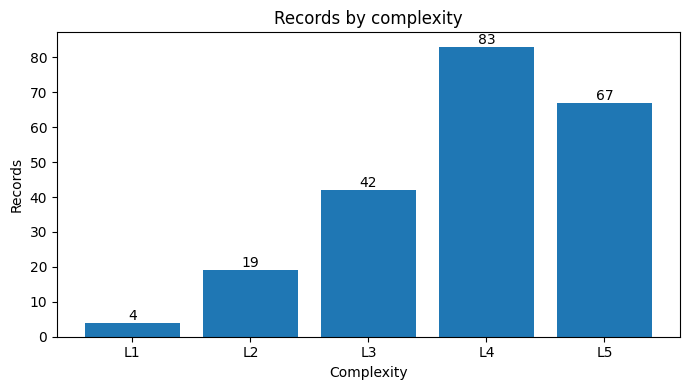

saved plot: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/stats/records_by_kind.png


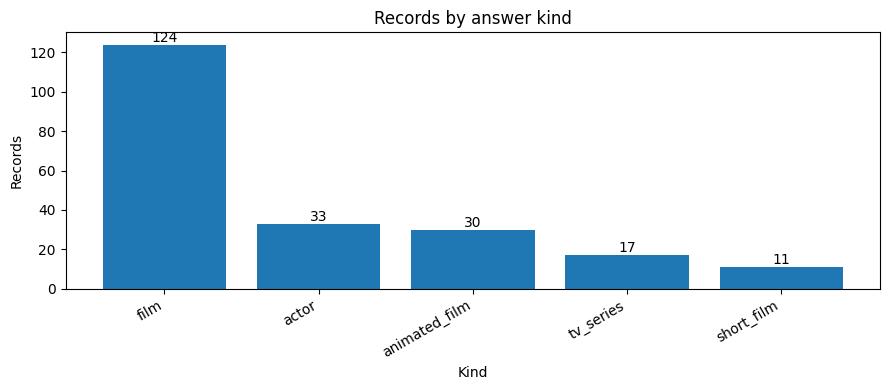

saved plot: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/stats/complexity_by_kind.png


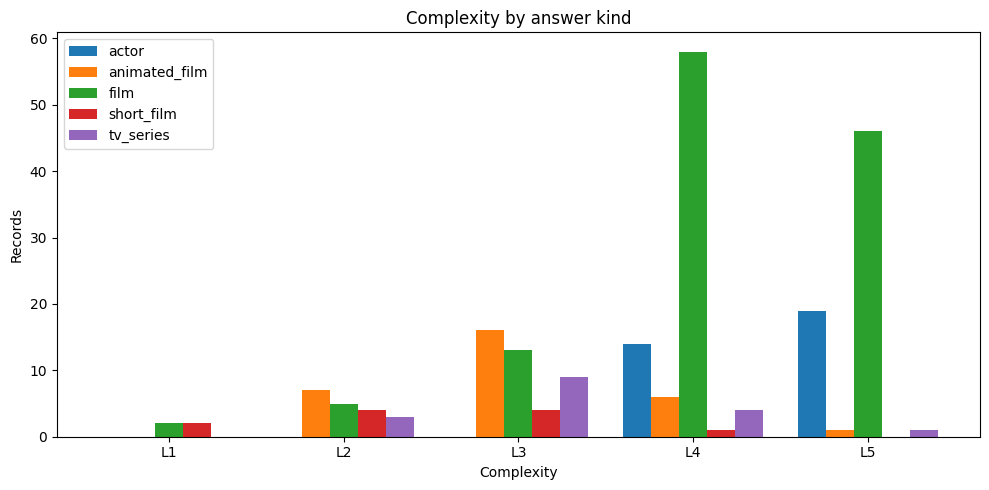

saved plot: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/stats/gold_count_histogram.png


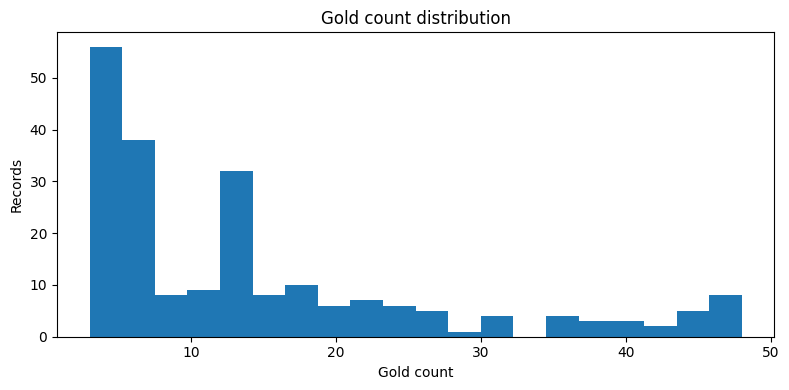

saved plot: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/stats/gold_count_by_complexity_boxplot.png


/var/folders/bw/k_6jpk4d4kv3sqq951fyzdyw0000gn/T/ipykernel_22016/2812279020.py:333: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


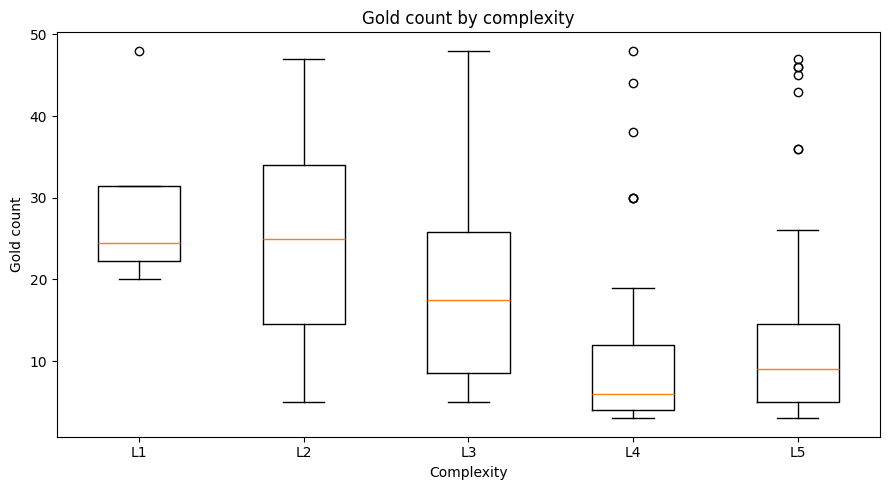

/var/folders/bw/k_6jpk4d4kv3sqq951fyzdyw0000gn/T/ipykernel_22016/2812279020.py:348: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=kind_order)


saved plot: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/stats/gold_count_by_kind_boxplot.png


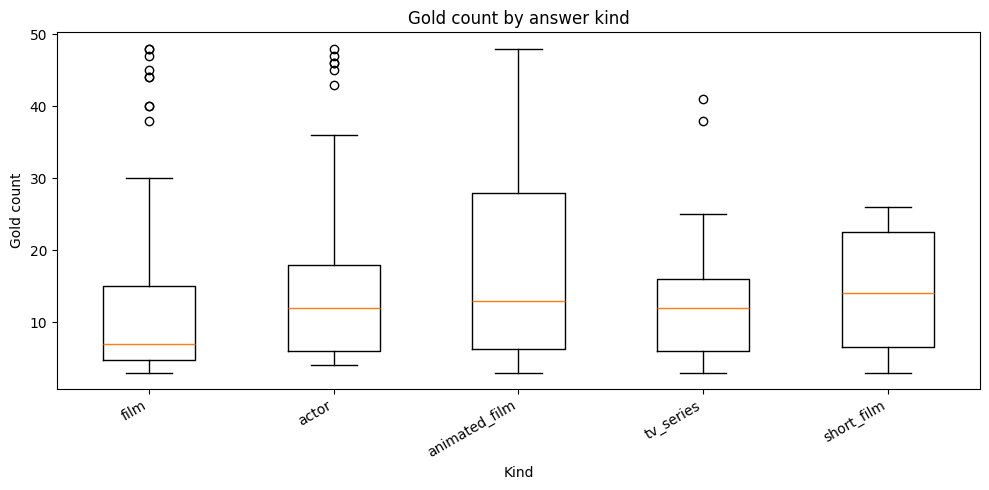

saved plot: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/stats/constraint_count_histogram.png


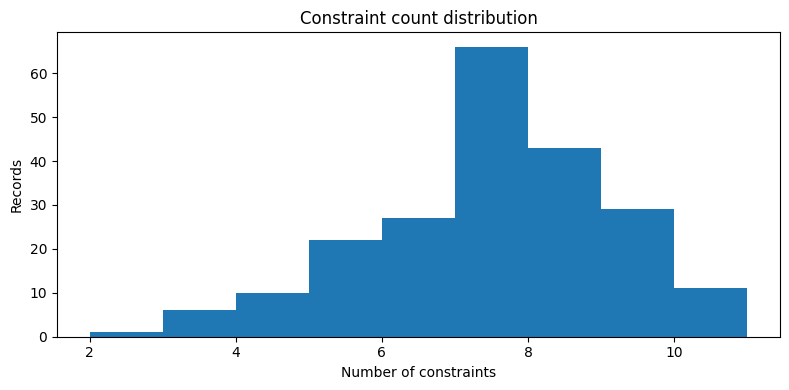

saved plot: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/stats/rating_type_counts.png


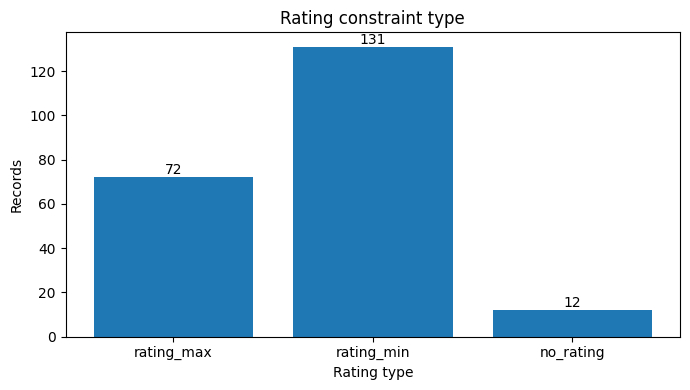

saved plot: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/stats/bridge_pattern_counts.png


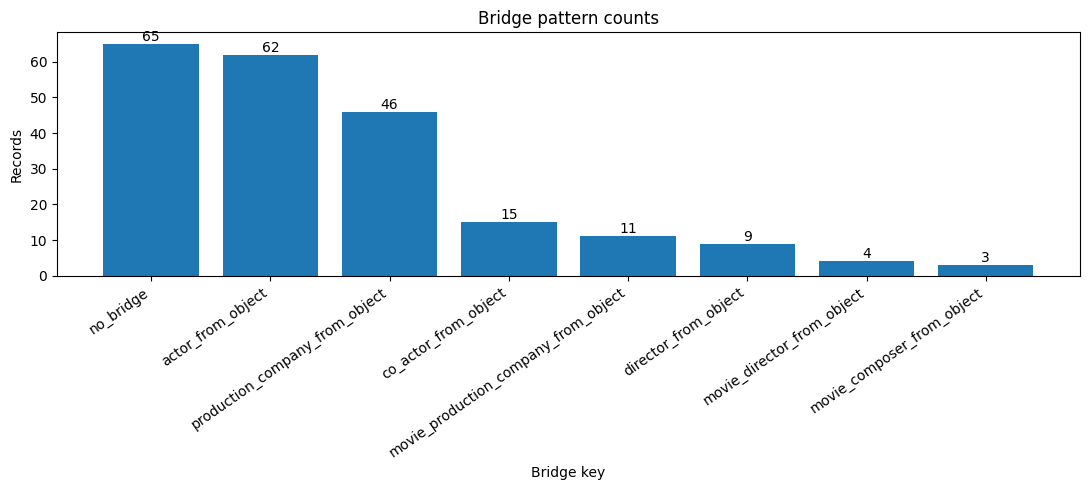

saved plot: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/stats/year_boundary_distribution.png


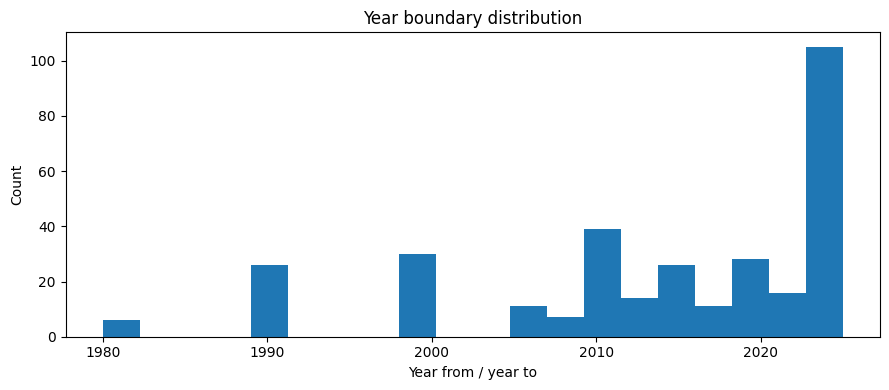

saved plot: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/stats/exact_year_vs_range_year.png


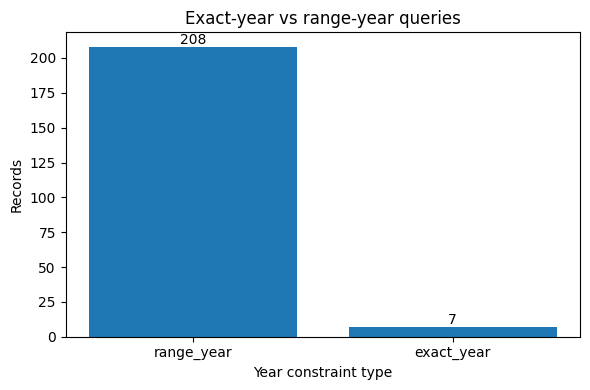

saved plot: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/stats/actor_distinct_evidence_titles.png


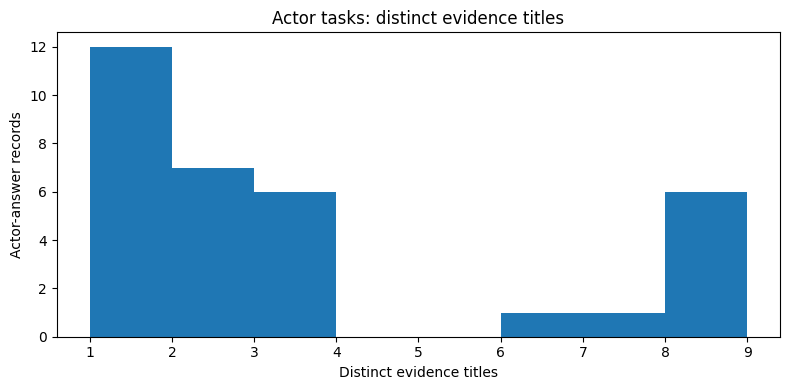

saved plot: /Users/matvey/Desktop/multihop benchmark/multihop_benchmark_modular/out_wikidata_benchmark/domain_outputs/stats/actor_max_per_evidence_title.png


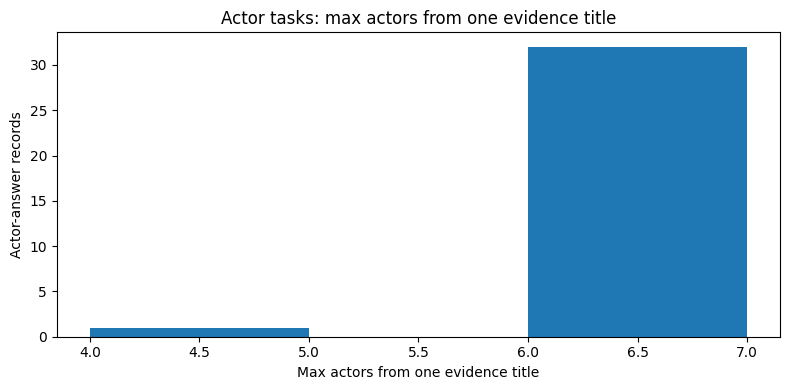


Top 20 records by gold_count:


,id,complexity,kind,gold_count,constraint_count,bridge_key,query_text_ru
45,movie_l3_0084,L3,film,48,6,no_bridge,"Назови 5 полнометражных фильмов, жанра «комеди..."
1,movie_l1_0006,L1,film,48,3,no_bridge,"Назови 5 полнометражных фильмов, с рейтингом I..."
73,movie_l4_0116,L4,actor,48,8,co_actor_from_object,"Назови 3 актёров, которые снимались в полномет..."
159,movie_l3_0218,L3,animated_film,48,7,no_bridge,"Назови 5 мультфильмов, жанра «драма», в период..."
104,movie_l5_0152,L5,actor,47,8,co_actor_from_object,"Назови 3 актёров, которые снимались в полномет..."
6,movie_l2_0023,L2,film,47,4,no_bridge,"Назови 5 полнометражных фильмов, жанра «трилле..."
112,movie_l5_0160,L5,actor,46,8,co_actor_from_object,"Назови 3 актёров, которые снимались в полномет..."
111,movie_l5_0159,L5,actor,46,10,co_actor_from_object,"Назови 3 актёров, которые снимались в полномет..."
152,movie_l3_0210,L3,film,45,7,no_bridge,"Назови 5 полнометражных фильмов, жанра «боевик..."
12,movie_l2_0029,L2,animated_film,45,4,no_bridge,"Назови 5 мультфильмов, жанра «фильм ужасов», д..."



L4/L5 records by kind:


kind,actor,animated_film,film,short_film,tv_series
complexity,,,,,
L4,14,6,58,1,4
L5,19,1,46,0,1



Gold completeness:


,complexity,gold_completeness,records
0,L1,may_be_incomplete_due_to_wdqs,4
1,L2,may_be_incomplete_due_to_wdqs,12
2,L2,not_truncated,7
3,L3,may_be_incomplete_due_to_wdqs,21
4,L3,not_truncated,21
5,L4,may_be_incomplete_due_to_wdqs,3
6,L4,not_truncated,80
7,L5,may_be_incomplete_due_to_wdqs,8
8,L5,not_truncated,59



Bridge patterns by complexity:


bridge_key,actor_from_object,co_actor_from_object,director_from_object,movie_composer_from_object,movie_director_from_object,movie_production_company_from_object,no_bridge,production_company_from_object
complexity,,,,,,,,
L1,0,0,0,0,0,0,4,0
L2,0,0,0,0,0,0,19,0
L3,0,0,0,0,0,0,42,0
L4,37,3,6,2,4,5,0,26
L5,25,12,3,1,0,6,0,20


In [14]:
# ============================================================
# Dataset statistics and plots for cinema/movie domain
# ============================================================

from pathlib import Path
from collections import Counter, defaultdict
import json
import statistics
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# Config
# =========================

DATASET_PATH = Path("out_wikidata_benchmark/domain_outputs/cinema_filtered_gold_le_50.jsonl")

STATS_DIR = Path("out_wikidata_benchmark/domain_outputs/stats")
STATS_DIR.mkdir(parents=True, exist_ok=True)

STATS_JSON_PATH = STATS_DIR / "cinema_filtered_stats.json"
STATS_CSV_PATH = STATS_DIR / "cinema_filtered_record_stats.csv"


# =========================
# Load
# =========================

records = []

with DATASET_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print("records:", len(records))


# =========================
# Helpers
# =========================

def gold_count(r):
    if r.get("gold_count") is not None:
        try:
            return int(r["gold_count"])
        except Exception:
            pass
    return len(r.get("gold_answer_qids") or [])


def kind_of(r):
    return (r.get("constraints") or {}).get("kind", "unknown")


def complexity_of(r):
    return r.get("complexity", "unknown")


def has_key(r, key):
    return key in (r.get("constraints") or {})


def is_exact_year(r):
    c = r.get("constraints") or {}
    return c.get("year_from") is not None and c.get("year_from") == c.get("year_to")


def year_from(r):
    return (r.get("constraints") or {}).get("year_from")


def year_to(r):
    return (r.get("constraints") or {}).get("year_to")


def year_span(r):
    c = r.get("constraints") or {}
    yf = c.get("year_from")
    yt = c.get("year_to")
    if yf is None or yt is None:
        return None
    return int(yt) - int(yf)


def constraint_count(r):
    c = r.get("constraints") or {}
    return len([k for k, v in c.items() if v is not None and v is not False and v != "" and v != [] and v != {}])


def rating_type(r):
    c = r.get("constraints") or {}
    if "rating_imdb_min" in c or "movie_rating_imdb_min" in c:
        return "rating_min"
    if "rating_imdb_max" in c or "movie_rating_imdb_max" in c:
        return "rating_max"
    return "no_rating"


def has_votes(r):
    c = r.get("constraints") or {}
    return "votes_imdb_min" in c or "movie_votes_imdb_min" in c


def has_runtime(r):
    c = r.get("constraints") or {}
    return any(k in c for k in [
        "runtime_min_minutes",
        "runtime_max_minutes",
        "movie_runtime_min_minutes",
        "movie_runtime_max_minutes",
    ])


def bridge_keys(r):
    c = r.get("constraints") or {}
    keys = []
    for k in c:
        if k.endswith("_from_object") or k.endswith("_same_as_object"):
            keys.append(k)
    return keys


def first_bridge_key(r):
    keys = bridge_keys(r)
    return keys[0] if keys else "no_bridge"


def gold_completeness_status(r):
    meta = r.get("gold_collection_meta") or {}
    if meta.get("gold_truncated_by_local_limit"):
        return "truncated_by_local_limit"
    if meta.get("gold_may_be_incomplete_due_to_wdqs_limit"):
        return "may_be_incomplete_due_to_wdqs"
    return "not_truncated"


def evidence_distinct_titles(r):
    meta = r.get("gold_collection_meta") or {}
    ev = meta.get("evidence_by_answer") or []
    if not ev:
        return None
    return len(set(e.get("evidence_title_qid") or e.get("evidence_imdb_id") for e in ev))


def evidence_max_per_title(r):
    meta = r.get("gold_collection_meta") or {}
    ev = meta.get("evidence_by_answer") or []
    if not ev:
        return None
    cnt = Counter(e.get("evidence_title_qid") or e.get("evidence_imdb_id") for e in ev)
    return max(cnt.values()) if cnt else None


# =========================
# Per-record stats dataframe
# =========================

rows = []

for r in records:
    rows.append({
        "id": r.get("id"),
        "complexity": complexity_of(r),
        "kind": kind_of(r),
        "gold_count": gold_count(r),
        "requested_count": r.get("requested_count"),
        "constraint_count": constraint_count(r),
        "year_from": year_from(r),
        "year_to": year_to(r),
        "year_span": year_span(r),
        "exact_year": is_exact_year(r),
        "rating_type": rating_type(r),
        "has_votes": has_votes(r),
        "has_runtime": has_runtime(r),
        "bridge_key": first_bridge_key(r),
        "gold_completeness": gold_completeness_status(r),
        "evidence_distinct_titles": evidence_distinct_titles(r),
        "evidence_max_per_title": evidence_max_per_title(r),
        "query_text_ru": r.get("query_text_ru"),
        "query_text_en": r.get("query_text_en"),
    })

df = pd.DataFrame(rows)

display(df.head(10))


# =========================
# Summary stats
# =========================

summary = {
    "records_total": len(records),
    "counts_by_complexity": dict(Counter(df["complexity"])),
    "counts_by_kind": dict(Counter(df["kind"])),
    "counts_by_complexity_and_kind": {
        lvl: dict(Counter(df[df["complexity"] == lvl]["kind"]))
        for lvl in sorted(df["complexity"].unique())
    },
    "gold_count": {
        "min": int(df["gold_count"].min()),
        "max": int(df["gold_count"].max()),
        "mean": round(float(df["gold_count"].mean()), 2),
        "median": round(float(df["gold_count"].median()), 2),
    },
    "constraint_count": {
        "min": int(df["constraint_count"].min()),
        "max": int(df["constraint_count"].max()),
        "mean": round(float(df["constraint_count"].mean()), 2),
        "median": round(float(df["constraint_count"].median()), 2),
    },
    "exact_year_count": int(df["exact_year"].sum()),
    "exact_year_share": round(float(df["exact_year"].mean()), 4),
    "rating_type_counts": dict(Counter(df["rating_type"])),
    "has_votes_count": int(df["has_votes"].sum()),
    "has_runtime_count": int(df["has_runtime"].sum()),
    "bridge_counts": dict(Counter(df["bridge_key"])),
    "gold_completeness_counts": dict(Counter(df["gold_completeness"])),
    "missing_local_validator": sum(1 for r in records if not r.get("local_validator")),
    "missing_gold_collection_meta": sum(1 for r in records if not r.get("gold_collection_meta")),
    "records_gold_lt_requested": int((df["gold_count"] < df["requested_count"]).sum()),
}

print(json.dumps(summary, ensure_ascii=False, indent=2))


# =========================
# Save stats
# =========================

with STATS_JSON_PATH.open("w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

df.to_csv(STATS_CSV_PATH, index=False)

print("stats json:", STATS_JSON_PATH.resolve())
print("record stats csv:", STATS_CSV_PATH.resolve())


# ============================================================
# Plots
# ============================================================

def save_plot(name):
    path = STATS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180)
    print("saved plot:", path.resolve())


# -------------------------
# 1. Records by complexity
# -------------------------

plt.figure(figsize=(7, 4))
order = ["L1", "L2", "L3", "L4", "L5"]
counts = [summary["counts_by_complexity"].get(x, 0) for x in order]
plt.bar(order, counts)
plt.title("Records by complexity")
plt.xlabel("Complexity")
plt.ylabel("Records")
for x, y in zip(order, counts):
    plt.text(x, y, str(y), ha="center", va="bottom")
save_plot("records_by_complexity.png")
plt.show()


# -------------------------
# 2. Records by kind
# -------------------------

plt.figure(figsize=(9, 4))
kind_counts = Counter(df["kind"])
kinds = [k for k, _ in kind_counts.most_common()]
vals = [kind_counts[k] for k in kinds]
plt.bar(kinds, vals)
plt.title("Records by answer kind")
plt.xlabel("Kind")
plt.ylabel("Records")
plt.xticks(rotation=30, ha="right")
for x, y in zip(kinds, vals):
    plt.text(x, y, str(y), ha="center", va="bottom")
save_plot("records_by_kind.png")
plt.show()


# -------------------------
# 3. Complexity x kind stacked-style grouped bars
# -------------------------

pivot = pd.crosstab(df["complexity"], df["kind"]).reindex(order).fillna(0)

plt.figure(figsize=(10, 5))
x = range(len(pivot.index))
width = 0.8 / max(1, len(pivot.columns))

for i, col in enumerate(pivot.columns):
    offsets = [v + (i - len(pivot.columns) / 2) * width + width / 2 for v in x]
    plt.bar(offsets, pivot[col].values, width=width, label=col)

plt.title("Complexity by answer kind")
plt.xlabel("Complexity")
plt.ylabel("Records")
plt.xticks(list(x), pivot.index)
plt.legend()
save_plot("complexity_by_kind.png")
plt.show()


# -------------------------
# 4. Gold count histogram
# -------------------------

plt.figure(figsize=(8, 4))
plt.hist(df["gold_count"], bins=20)
plt.title("Gold count distribution")
plt.xlabel("Gold count")
plt.ylabel("Records")
save_plot("gold_count_histogram.png")
plt.show()


# -------------------------
# 5. Gold count by complexity
# -------------------------

plt.figure(figsize=(9, 5))
data = [df[df["complexity"] == lvl]["gold_count"].values for lvl in order if lvl in set(df["complexity"])]
labels = [lvl for lvl in order if lvl in set(df["complexity"])]
plt.boxplot(data, labels=labels)
plt.title("Gold count by complexity")
plt.xlabel("Complexity")
plt.ylabel("Gold count")
save_plot("gold_count_by_complexity_boxplot.png")
plt.show()


# -------------------------
# 6. Gold count by kind
# -------------------------

plt.figure(figsize=(10, 5))
kind_order = [k for k, _ in Counter(df["kind"]).most_common()]
data = [df[df["kind"] == k]["gold_count"].values for k in kind_order]
plt.boxplot(data, labels=kind_order)
plt.title("Gold count by answer kind")
plt.xlabel("Kind")
plt.ylabel("Gold count")
plt.xticks(rotation=30, ha="right")
save_plot("gold_count_by_kind_boxplot.png")
plt.show()


# -------------------------
# 7. Constraint count distribution
# -------------------------

plt.figure(figsize=(8, 4))
plt.hist(df["constraint_count"], bins=range(int(df["constraint_count"].min()), int(df["constraint_count"].max()) + 2))
plt.title("Constraint count distribution")
plt.xlabel("Number of constraints")
plt.ylabel("Records")
save_plot("constraint_count_histogram.png")
plt.show()


# -------------------------
# 8. Rating type counts
# -------------------------

plt.figure(figsize=(7, 4))
rating_counts = Counter(df["rating_type"])
rating_labels = list(rating_counts.keys())
rating_vals = [rating_counts[k] for k in rating_labels]
plt.bar(rating_labels, rating_vals)
plt.title("Rating constraint type")
plt.xlabel("Rating type")
plt.ylabel("Records")
for x, y in zip(rating_labels, rating_vals):
    plt.text(x, y, str(y), ha="center", va="bottom")
save_plot("rating_type_counts.png")
plt.show()


# -------------------------
# 9. Bridge key counts
# -------------------------

plt.figure(figsize=(11, 5))
bridge_counts = Counter(df["bridge_key"])
bridge_labels = [k for k, _ in bridge_counts.most_common()]
bridge_vals = [bridge_counts[k] for k in bridge_labels]
plt.bar(bridge_labels, bridge_vals)
plt.title("Bridge pattern counts")
plt.xlabel("Bridge key")
plt.ylabel("Records")
plt.xticks(rotation=35, ha="right")
for x, y in zip(bridge_labels, bridge_vals):
    plt.text(x, y, str(y), ha="center", va="bottom")
save_plot("bridge_pattern_counts.png")
plt.show()


# -------------------------
# 10. Year distribution
# -------------------------

year_values = []

for _, row in df.iterrows():
    yf = row["year_from"]
    yt = row["year_to"]
    if pd.notna(yf):
        year_values.append(int(yf))
    if pd.notna(yt) and yt != yf:
        year_values.append(int(yt))

if year_values:
    plt.figure(figsize=(9, 4))
    plt.hist(year_values, bins=20)
    plt.title("Year boundary distribution")
    plt.xlabel("Year from / year to")
    plt.ylabel("Count")
    save_plot("year_boundary_distribution.png")
    plt.show()


# -------------------------
# 11. Exact-year vs range-year
# -------------------------

plt.figure(figsize=(6, 4))
exact_counts = Counter(df["exact_year"])
labels = ["range_year", "exact_year"]
vals = [exact_counts.get(False, 0), exact_counts.get(True, 0)]
plt.bar(labels, vals)
plt.title("Exact-year vs range-year queries")
plt.xlabel("Year constraint type")
plt.ylabel("Records")
for x, y in zip(labels, vals):
    plt.text(x, y, str(y), ha="center", va="bottom")
save_plot("exact_year_vs_range_year.png")
plt.show()


# -------------------------
# 12. Actor evidence diagnostics
# -------------------------

actor_df = df[df["kind"] == "actor"].copy()

if len(actor_df) > 0:
    plt.figure(figsize=(8, 4))
    vals = actor_df["evidence_distinct_titles"].dropna()
    if len(vals) > 0:
        plt.hist(vals, bins=range(int(vals.min()), int(vals.max()) + 2))
        plt.title("Actor tasks: distinct evidence titles")
        plt.xlabel("Distinct evidence titles")
        plt.ylabel("Actor-answer records")
        save_plot("actor_distinct_evidence_titles.png")
        plt.show()

    plt.figure(figsize=(8, 4))
    vals = actor_df["evidence_max_per_title"].dropna()
    if len(vals) > 0:
        plt.hist(vals, bins=range(int(vals.min()), int(vals.max()) + 2))
        plt.title("Actor tasks: max actors from one evidence title")
        plt.xlabel("Max actors from one evidence title")
        plt.ylabel("Actor-answer records")
        save_plot("actor_max_per_evidence_title.png")
        plt.show()


# =========================
# Useful printed tables
# =========================

print("\nTop 20 records by gold_count:")
display(
    df.sort_values("gold_count", ascending=False)[
        ["id", "complexity", "kind", "gold_count", "constraint_count", "bridge_key", "query_text_ru"]
    ].head(20)
)

print("\nL4/L5 records by kind:")
display(
    pd.crosstab(
        df[df["complexity"].isin(["L4", "L5"])]["complexity"],
        df[df["complexity"].isin(["L4", "L5"])]["kind"],
    )
)

print("\nGold completeness:")
display(
    df.groupby(["complexity", "gold_completeness"])
      .size()
      .reset_index(name="records")
      .sort_values(["complexity", "gold_completeness"])
)

print("\nBridge patterns by complexity:")
display(
    pd.crosstab(df["complexity"], df["bridge_key"])
)